# Separated vs Shared Encoding notebook scaffold

Scaffold for comparing the full baseline model against feature-group-specific models (financial, creative, metadata). The logic is unchanged; this notebook focuses on clear structure, consistent globals, and organized artifacts for plots/results.

## Intro & goals
We compare the shared-encoder baseline against three feature-group-specific models while keeping the architecture fixed. The goal is to assess whether semantic separation helps or hurts predictive performance.

## Outline
- Intro & goals
- Imports & config
- Artifacts & output structure
- Baseline architecture reference
- Data prep & feature groups
- Loader helpers
- Model setup
- Training loop
- Predictions & evaluation
- Results aggregation
- Plotting
- Ensemble variants
- Fusion experiments
- Comprehensive comparison
- Test set evaluation
- Notes

## Imports & config
Set paths, device, and reproducibility settings before data prep. Artifacts are stored under the notebook's `artifacts/` directory.

In [36]:
import os
import sys
import time
import json
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from pathlib import Path
import matplotlib.pyplot as plt
from collections import defaultdict

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))
ARTIFACT_ROOT = NOTEBOOK_DIR / "artifacts" / "seperated_vs_shared_encoding"

import data.encode_features as enc
from models.model import TabularRegressor
from models.encoders import SharedTabularEncoder
from models.heads import RegressionHead

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Reproducibility
def seed_everything(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(42)

Using device: cpu


## Artifacts & output structure
Organize outputs (predictions, histories, plots, summaries, checkpoints) under the notebook's artifacts folder for reproducibility.

In [37]:
# Create organized directory structure for outputs
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = ARTIFACT_ROOT
PREDICTIONS_DIR = RESULTS_DIR / "predictions"
HISTORIES_DIR = RESULTS_DIR / "training_histories"
PLOTS_DIR = RESULTS_DIR / "plots"
SUMMARIES_DIR = RESULTS_DIR / "summaries"
CHECKPOINTS_DIR = RESULTS_DIR / "checkpoints"

# Create all directories
for dir_path in [PREDICTIONS_DIR, HISTORIES_DIR, PLOTS_DIR, SUMMARIES_DIR, CHECKPOINTS_DIR]:
    dir_path.mkdir(parents=True, exist_ok=True)

print(f"Results will be saved to: {RESULTS_DIR.absolute()}")
print(f"  - Predictions: {PREDICTIONS_DIR}")
print(f"  - Histories: {HISTORIES_DIR}")
print(f"  - Plots: {PLOTS_DIR}")
print(f"  - Summaries: {SUMMARIES_DIR}")
print(f"  - Checkpoints: {CHECKPOINTS_DIR}")

Results will be saved to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding
  - Predictions: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\predictions
  - Histories: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\training_histories
  - Plots: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\plots
  - Summaries: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\summaries
  - Checkpoints: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\checkpoints


## Baseline architecture reference
We inspect the shared-encoder baseline from `src/models/model.py` and reuse it unchanged for all feature-group models.

In [38]:
# Load baseline artifacts (config, history, metrics, checkpoint)
BASELINE_ROOT = NOTEBOOK_DIR / "artifacts" / "baseline"
BASELINE_RESULTS = BASELINE_ROOT / "results"
BASELINE_CHECKPOINTS = BASELINE_ROOT / "checkpoints"

baseline_config_path = BASELINE_RESULTS / "config.json"
baseline_history_path = BASELINE_RESULTS / "training_history.csv"
baseline_metrics_path = BASELINE_RESULTS / "test_metrics.csv"
baseline_model_path = BASELINE_CHECKPOINTS / "tabular_regressor.pt"

with baseline_config_path.open("r") as f:
    baseline_cfg = json.load(f)

baseline_history_df = pd.read_csv(baseline_history_path)
baseline_metrics_df = pd.read_csv(baseline_metrics_path)

BASELINE_ENCODER_HIDDEN = tuple(baseline_cfg["encoder_hidden"])
BASELINE_HEAD_HIDDEN = tuple(baseline_cfg.get("head_hidden", []))
BASELINE_DROPOUT = float(baseline_cfg.get("dropout", 0.1))
BATCH_SIZE = int(baseline_cfg.get("batch_size", 256))

# Define baseline architecture specification (from baseline artifacts)
BASELINE_ARCHITECTURE = {
    "class": "TabularRegressor",
    "mode": "shared",
    "encoder": "SharedTabularEncoder",
    "encoder_hidden": BASELINE_ENCODER_HIDDEN,
    "head_hidden": BASELINE_HEAD_HIDDEN,
    "head_class": "RegressionHead",
    "dropout": BASELINE_DROPOUT,
    "description": f"SharedTabularEncoder: input -> {' -> '.join(str(h) for h in BASELINE_ENCODER_HIDDEN)} -> output. RegressionHead: encoder_out -> 1"
}

# Document architecture details
encoder_hidden_str = ", ".join(str(h) for h in BASELINE_ENCODER_HIDDEN)
encoder_path = " -> ".join(
    [f"Linear({h}) -> ReLU -> Dropout({BASELINE_DROPOUT})" for h in BASELINE_ENCODER_HIDDEN]
)
if BASELINE_HEAD_HIDDEN:
    head_hidden_str = ", ".join(str(h) for h in BASELINE_HEAD_HIDDEN)
    head_path = " -> ".join(
        [
            *(f"Linear({h}) -> ReLU -> Dropout({BASELINE_DROPOUT})" for h in BASELINE_HEAD_HIDDEN),
            "Linear(1)",
        ]
    )
else:
    head_hidden_str = "none"
    head_path = "Linear(1)"

print("=" * 80)
print("BASELINE ARCHITECTURE SPECIFICATION")
print("=" * 80)
for key, value in BASELINE_ARCHITECTURE.items():
    print(f"{key:20s}: {value}")
print("=" * 80)
print("\nArchitecture Details:")
print(f"- Encoder: SharedTabularEncoder with hidden layers ({encoder_hidden_str})")
print(f"- Encoder path: input_dim -> {encoder_path}")
print(f"- Head: RegressionHead (hidden layers: {head_hidden_str})")
print(f"- Head path: {head_path}")
print("- Output: Single scalar prediction (log-transformed gross)")
print("=" * 80)

BASELINE ARCHITECTURE SPECIFICATION
class               : TabularRegressor
mode                : shared
encoder             : SharedTabularEncoder
encoder_hidden      : (512, 256, 128, 64)
head_hidden         : ()
head_class          : RegressionHead
dropout             : 0.1
description         : SharedTabularEncoder: input -> 512 -> 256 -> 128 -> 64 -> output. RegressionHead: encoder_out -> 1

Architecture Details:
- Encoder: SharedTabularEncoder with hidden layers (512, 256, 128, 64)
- Encoder path: input_dim -> Linear(512) -> ReLU -> Dropout(0.1) -> Linear(256) -> ReLU -> Dropout(0.1) -> Linear(128) -> ReLU -> Dropout(0.1) -> Linear(64) -> ReLU -> Dropout(0.1)
- Head: RegressionHead (hidden layers: none)
- Head path: Linear(1)
- Output: Single scalar prediction (log-transformed gross)


## Data prep & feature groups
Load train/val/test splits and apply the same preprocessing pipeline as the baseline. Define semantic feature groups for focused modeling.

In [39]:
# Data configuration
ALL_FEATURES_DIR = "../data/processed/all_features"
TARGET_COL = "gross"

NUMERIC_COLS = ["budget", "year", "votes", "runtime", "score"]
CAT_COLS = ["company", "genre", "director", "writer", "star", "country", "rating"]

# Baseline shared feature order (enc.prepare_features): numerics + frequency-encoded categoricals
BASELINE_FEATURE_NAMES = NUMERIC_COLS + CAT_COLS

# Feature groups (Semantic Categorization)
FEATURE_GROUPS = {
    "baseline": {
        "name": "All Features (Baseline)",
        "numeric_indices": [0, 1, 2, 3, 4],  # budget, year, votes, runtime, score
        "categorical_indices": [0, 1, 2, 3, 4, 5, 6],  # company, genre, director, writer, star, country, rating
    },
    "financial": {
        "name": "Financial (Economic Context)",
        "numeric_indices": [0, 1, 2],  # budget, year, votes
        "categorical_indices": [0],  # company
    },
    "creative": {
        "name": "Creative (Core Talent)",
        "numeric_indices": [],
        "categorical_indices": [1, 2, 3, 4],  # genre, director, writer, star
    },
    "metadata": {
        "name": "Metadata (Cataloging Specs)",
        "numeric_indices": [3, 4],  # runtime, score
        "categorical_indices": [5, 6],  # country, rating
    },
}

In [40]:
# Load processed splits (same as baseline notebook 03)
data_dir = PROJECT_ROOT / "data" / "processed" / "all_features"

train_df = pd.read_csv(data_dir / "train.csv")
val_df   = pd.read_csv(data_dir / "val.csv")
test_df  = pd.read_csv(data_dir / "test.csv")

baseline_X_train, baseline_X_val, baseline_X_test, baseline_y_train, baseline_y_val, baseline_y_test, baseline_artifacts = enc.prepare_features(
    train_df, val_df, test_df
)
y_train = baseline_y_train
y_val   = baseline_y_val
y_test  = baseline_y_test
print(baseline_X_train.shape)


(3804, 12)


## Loader helpers
Build feature-group-specific loaders by slicing numeric/categorical subsets and assembling shared-mode tensors.

In [41]:
def _group_shared_indices(group_config):
    num_idx = group_config["numeric_indices"]
    cat_idx = group_config["categorical_indices"]
    return list(num_idx) + [len(NUMERIC_COLS) + i for i in cat_idx]

group_indices = {k: _group_shared_indices(v) for k, v in FEATURE_GROUPS.items()}

# Slice the SAME 12-d baseline vector into groups
group_X_train = {k: baseline_X_train[:, idxs].astype(np.float32) for k, idxs in group_indices.items()}
group_X_val   = {k: baseline_X_val[:, idxs].astype(np.float32) for k, idxs in group_indices.items()}
group_X_test  = {k: baseline_X_test[:, idxs].astype(np.float32) for k, idxs in group_indices.items()}

# Targets (same for all groups)
y_train = baseline_y_train.astype(np.float32)
y_val   = baseline_y_val.astype(np.float32)
y_test  = baseline_y_test.astype(np.float32)

# Sanity print
for k in ["baseline", "financial", "creative", "metadata"]:
    print(k, group_X_train[k].shape, [BASELINE_FEATURE_NAMES[i] for i in group_indices[k]])


baseline (3804, 12) ['budget', 'year', 'votes', 'runtime', 'score', 'company', 'genre', 'director', 'writer', 'star', 'country', 'rating']
financial (3804, 4) ['budget', 'year', 'votes', 'company']
creative (3804, 4) ['genre', 'director', 'writer', 'star']
metadata (3804, 4) ['runtime', 'score', 'country', 'rating']


In [42]:
# Build DataLoaders from the baseline 12-d shared vector by slicing per group

def _group_shared_indices(group_config):
    num_idx = group_config["numeric_indices"]
    cat_idx = group_config["categorical_indices"]
    return list(num_idx) + [len(NUMERIC_COLS) + i for i in cat_idx]

def create_group_loaders(group_key, group_config, batch_size=BATCH_SIZE):
    idxs = _group_shared_indices(group_config)

    Xtr = baseline_X_train[:, idxs].astype(np.float32)
    Xva = baseline_X_val[:, idxs].astype(np.float32)
    Xte = baseline_X_test[:, idxs].astype(np.float32)

    ytr = baseline_y_train.astype(np.float32)
    yva = baseline_y_val.astype(np.float32)
    yte = baseline_y_test.astype(np.float32)

    train_ds = TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr))
    val_ds   = TensorDataset(torch.from_numpy(Xva), torch.from_numpy(yva))
    test_ds  = TensorDataset(torch.from_numpy(Xte), torch.from_numpy(yte))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=False, num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False, num_workers=0)

    feature_names = [BASELINE_FEATURE_NAMES[i] for i in idxs]

    return {
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "input_dim": Xtr.shape[1],
        "idxs": idxs,
        "feature_names": feature_names,
    }

data_loaders = {}
for group_key, group_config in FEATURE_GROUPS.items():
    data_loaders[group_key] = create_group_loaders(group_key, group_config, batch_size=BATCH_SIZE)

print("data_loaders keys:", list(data_loaders.keys()))
for k in data_loaders:
    xb, yb = next(iter(data_loaders[k]["train_loader"]))
    print(k, xb.shape, "->", data_loaders[k]["feature_names"])


data_loaders keys: ['baseline', 'financial', 'creative', 'metadata']
baseline torch.Size([256, 12]) -> ['budget', 'year', 'votes', 'runtime', 'score', 'company', 'genre', 'director', 'writer', 'star', 'country', 'rating']
financial torch.Size([256, 4]) -> ['budget', 'year', 'votes', 'company']
creative torch.Size([256, 4]) -> ['genre', 'director', 'writer', 'star']
metadata torch.Size([256, 4]) -> ['runtime', 'score', 'country', 'rating']


## Model setup
Instantiate the baseline and feature-group models with the same shared-encoder architecture and prepare result tracking structures.

In [43]:
# Initialize models using exact baseline architecture (SHARED mode)
models = {}

from dataclasses import dataclass

@dataclass
class EarlyStopConfig:
    patience: int = 25
    min_delta: float = 0.0
    restore_best: bool = True

@dataclass
class SchedConfig:
    enabled: bool = True
    mode: str = "min"
    factor: float = 0.5
    patience: int = 8
    min_lr: float = 1e-6
    threshold: float = 1e-4

def load_checkpoint_state_dict(checkpoint_path, device):
    """Load a checkpoint safely and return a model state_dict."""
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    if isinstance(ckpt, dict):
        for key in ("state_dict", "model_state_dict", "model"):
            if key in ckpt and isinstance(ckpt[key], dict):
                return ckpt[key]
    return ckpt

for group_key, group_config in FEATURE_GROUPS.items():
    loader_info = data_loaders[group_key]
    
    # Get shared input dimension
    input_dim = loader_info["input_dim"]
    
    # Instantiate model with baseline architecture (SHARED mode matching 03_baseline_model.ipynb)
    model = TabularRegressor(
        mode="shared",
        input_dim=input_dim,
        encoder_hidden=BASELINE_ENCODER_HIDDEN,
        head_hidden=BASELINE_HEAD_HIDDEN,
        dropout=BASELINE_DROPOUT,
    ).to(device)

    if group_key == "baseline":
        state_dict = load_checkpoint_state_dict(baseline_model_path, device)
        model.load_state_dict(state_dict)
        model.eval()
    
    models[group_key] = {
        "model": model,
        "group_name": group_config["name"],
        "input_dim": input_dim,
    }

# Count parameters
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n" + "="*80)
print("MODEL ARCHITECTURE VERIFICATION")
print("="*80)
print(f"All models use baseline architecture: {BASELINE_ARCHITECTURE['description']}")
print("\nModel Parameter Counts:")
for group_key, model_info in models.items():
    n_params = count_params(model_info["model"])
    print(f"  {model_info['group_name']:30s} (input_dim={model_info['input_dim']}): {n_params:7d} params")
print("="*80)

# Initialize results history tracking
results_history = defaultdict(lambda: {
    "epoch": [],
    "train_mse": [],
    "train_mae": [],
    "val_mse": [],
    "val_mae": [],
    "epoch_time": [],
})

# Seed baseline history from baseline artifacts (so we don't retrain it)
if "baseline" in FEATURE_GROUPS:
    baseline_columns = set(baseline_history_df.columns)
    def pick_col(options):
        for col in options:
            if col in baseline_columns:
                return col
        return None
    
    epoch_col = pick_col(["epoch", "Epoch"])
    train_mse_col = pick_col(["train_mse", "train_loss", "train_mse_loss"])
    val_mse_col = pick_col(["val_mse", "val_loss", "val_mse_loss"])
    train_mae_col = pick_col(["train_mae", "train_mae_loss", "train_mae_metric"])
    val_mae_col = pick_col(["val_mae", "val_mae_loss", "val_mae_metric"])
    epoch_time_col = pick_col(["epoch_time", "time", "epoch_seconds"])

    if all([train_mse_col, val_mse_col, train_mae_col, val_mae_col]):
        epoch_vals = (
            baseline_history_df[epoch_col].tolist()
            if epoch_col is not None
            else list(range(1, len(baseline_history_df) + 1))
        )
        baseline_history = {
            "epoch": epoch_vals,
            "train_mse": baseline_history_df[train_mse_col].tolist(),
            "train_mae": baseline_history_df[train_mae_col].tolist(),
            "val_mse": baseline_history_df[val_mse_col].tolist(),
            "val_mae": baseline_history_df[val_mae_col].tolist(),
            "epoch_time": baseline_history_df[epoch_time_col].tolist() if epoch_time_col else [0.0] * len(baseline_history_df),
        }
        results_history["baseline"] = baseline_history
    else:
        print("Baseline history missing required columns; skipping baseline in results aggregation.")
        
print("baseline_X_train shape:", baseline_X_train.shape)
for k in ["financial","creative","metadata"]:
    xb, yb = next(iter(data_loaders[k]["train_loader"]))
    print(k, xb.shape)



MODEL ARCHITECTURE VERIFICATION
All models use baseline architecture: SharedTabularEncoder: input -> 512 -> 256 -> 128 -> 64 -> output. RegressionHead: encoder_out -> 1

Model Parameter Counts:
  All Features (Baseline)        (input_dim=12):  179201 params
  Financial (Economic Context)   (input_dim=4):  175105 params
  Creative (Core Talent)         (input_dim=4):  175105 params
  Metadata (Cataloging Specs)    (input_dim=4):  175105 params
baseline_X_train shape: (3804, 12)
financial torch.Size([256, 4])
creative torch.Size([256, 4])
metadata torch.Size([256, 4])


## Verification: architecture + dataset consistency
Check that all group models use the baseline encoder/heads, and that all feature groups come from the same train/val/test splits.

In [44]:
# Verify architecture and dataset consistency
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

print("\n" + "="*100)
print("ARCHITECTURE + DATASET CONSISTENCY CHECK")
print("="*100)

# ----------------------------
# Architecture checks
# ----------------------------
def _extract_linear_dims(module: nn.Module):
    dims = []
    for m in module.modules():
        if isinstance(m, nn.Linear):
            dims.append((m.in_features, m.out_features))
    return dims

def _extract_hidden_from_dims(dims, drop_last: bool = False):
    if not dims:
        return ()
    if drop_last and len(dims) > 0:
        dims = dims[:-1]
    return tuple(d[1] for d in dims)

def _print_model_arch(name, model: nn.Module):
    enc = getattr(model, "encoder", None)
    head = getattr(model, "head", None)
    enc_dims = _extract_linear_dims(enc) if enc is not None else []
    head_dims = _extract_linear_dims(head) if head is not None else []
    enc_hidden = _extract_hidden_from_dims(enc_dims, drop_last=False)
    head_hidden = _extract_hidden_from_dims(head_dims, drop_last=True)
    dropouts = [m.p for m in model.modules() if isinstance(m, nn.Dropout)]
    drop = dropouts[0] if dropouts else None
    print(f"\n{name}:")
    print(f"  encoder hidden: {enc_hidden}")
    print(f"  head hidden:    {head_hidden}")
    print(f"  dropout:        {drop}")
    return enc_hidden, head_hidden, drop

expected_enc = tuple(BASELINE_ENCODER_HIDDEN)
expected_head = tuple(BASELINE_HEAD_HIDDEN)
expected_drop = float(BASELINE_DROPOUT)

if "models" in globals():
    for g in ["baseline", "financial", "creative", "metadata"]:
        if g in models:
            enc_hidden, head_hidden, drop = _print_model_arch(models[g]["group_name"], models[g]["model"])
            ok = (enc_hidden == expected_enc) and (head_hidden == expected_head) and (drop == expected_drop)
            print(f"  matches baseline arch? {ok}")
else:
    print("Models not found. Run model initialization cell first.")

# ----------------------------
# Dataset checks
# ----------------------------
def _df_hash(df: pd.DataFrame) -> int:
    return int(pd.util.hash_pandas_object(df, index=True).sum())

if "train_df" in globals() and "val_df" in globals() and "test_df" in globals():
    train_hash = _df_hash(train_df)
    val_hash = _df_hash(val_df)
    test_hash = _df_hash(test_df)
    print("\nDataset hashes (train/val/test):")
    print(f"  train: {train_hash}")
    print(f"  val:   {val_hash}")
    print(f"  test:  {test_hash}")
    print(f"  sizes: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
else:
    print("Train/val/test DataFrames not found. Run data loading cell first.")

if "baseline_y_train" in globals() and "y_train" in globals():
    y_train_hash = int(pd.util.hash_pandas_object(pd.Series(y_train), index=True).sum())
    y_base_hash = int(pd.util.hash_pandas_object(pd.Series(baseline_y_train), index=True).sum())
    print("\nTarget hash check:")
    print(f"  y_train:    {y_train_hash}")
    print(f"  baseline_y_train: {y_base_hash}")
    print(f"  match? {y_train_hash == y_base_hash}")
else:
    print("y_train or baseline_y_train not found; skipping target hash check.")

print("="*100)


ARCHITECTURE + DATASET CONSISTENCY CHECK

All Features (Baseline):
  encoder hidden: (512, 256, 128, 64)
  head hidden:    ()
  dropout:        0.1
  matches baseline arch? True

Financial (Economic Context):
  encoder hidden: (512, 256, 128, 64)
  head hidden:    ()
  dropout:        0.1
  matches baseline arch? True

Creative (Core Talent):
  encoder hidden: (512, 256, 128, 64)
  head hidden:    ()
  dropout:        0.1
  matches baseline arch? True

Metadata (Cataloging Specs):
  encoder hidden: (512, 256, 128, 64)
  head hidden:    ()
  dropout:        0.1
  matches baseline arch? True

Dataset hashes (train/val/test):
  train: 4132826305927389816
  val:   11544018462430750819
  test:  8525744329735437979
  sizes: train=3804, val=815, test=816

Target hash check:
  y_train:    6967800666624515438
  baseline_y_train: 6967800666624515438
  match? True


## Training loop
Train all models with identical hyperparameters, track metrics per epoch, and save the best checkpoint by validation MSE.

In [45]:
# Training configuration (match baseline hyperparameters)
EPOCHS = int(baseline_cfg.get("epochs", 100))
LEARNING_RATE = float(baseline_cfg.get("lr", 1e-3))
WEIGHT_DECAY = float(baseline_cfg.get("weight_decay", 1e-4))

criterion = nn.MSELoss()

def train_epoch(model, optimizer, loader, device):
    """Train model for one epoch (shared mode)."""
    model.train()
    mse_sum, mae_sum, n = 0.0, 0.0, 0

    for X, y in loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        pred = model(X).squeeze()
        loss = criterion(pred, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        mse_sum += torch.sum((pred.detach() - y) ** 2).item()
        mae_sum += torch.sum(torch.abs(pred.detach() - y)).item()
        n += y.numel()

    return (mse_sum / n if n > 0 else 0.0), (mae_sum / n if n > 0 else 0.0)

@torch.no_grad()
def eval_epoch(model, loader, device):
    """Evaluate model on a loader (shared mode)."""
    model.eval()
    mse_sum, mae_sum, n = 0.0, 0.0, 0

    for X, y in loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        pred = model(X).squeeze()
        mse_sum += torch.sum((pred - y) ** 2).item()
        mae_sum += torch.sum(torch.abs(pred - y)).item()
        n += y.numel()

    return (mse_sum / n if n > 0 else 0.0), (mae_sum / n if n > 0 else 0.0)

# Training loop for all groups (skip baseline; it's loaded from artifacts)
train_group_keys = [k for k in models.keys() if k != "baseline"]

best_val_mse = {k: float("inf") for k in train_group_keys}
optimizers = {
    k: torch.optim.AdamW(models[k]["model"].parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    for k in train_group_keys
}

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    for group_key in train_group_keys:
        model = models[group_key]["model"]
        loader_info = data_loaders[group_key]
        optimizer = optimizers[group_key]

        # Train
        train_mse, train_mae = train_epoch(model, optimizer, loader_info["train_loader"], device)

        # Validate
        val_mse, val_mae = eval_epoch(model, loader_info["val_loader"], device)

        # Save best checkpoint
        if val_mse < best_val_mse[group_key]:
            best_val_mse[group_key] = val_mse
            checkpoint_path = CHECKPOINTS_DIR / f"{group_key}_best.pt"
            torch.save(model.state_dict(), checkpoint_path)

        # Record history
        results_history[group_key]["epoch"].append(epoch)
        results_history[group_key]["train_mse"].append(train_mse)
        results_history[group_key]["train_mae"].append(train_mae)
        results_history[group_key]["val_mse"].append(val_mse)
        results_history[group_key]["val_mae"].append(val_mae)
        results_history[group_key]["epoch_time"].append(time.time() - epoch_start)

        if epoch == 1 or epoch % 10 == 0 or epoch == EPOCHS:
            print(
                f"[{group_key}] Epoch {epoch:03d}/{EPOCHS} | "
                f"train MSE {train_mse:.6f} MAE {train_mae:.6f} | "
                f"val MSE {val_mse:.6f} MAE {val_mae:.6f}"
            )


[financial] Epoch 001/100 | train MSE 203.602648 MAE 12.183323 | val MSE 45.540490 MAE 4.502458
[creative] Epoch 001/100 | train MSE 202.927170 MAE 13.060593 | val MSE 134.546797 MAE 11.155631
[metadata] Epoch 001/100 | train MSE 155.239088 MAE 10.694604 | val MSE 16.535761 MAE 3.353426
[financial] Epoch 010/100 | train MSE 3.821494 MAE 1.540825 | val MSE 1.641635 MAE 0.963537
[creative] Epoch 010/100 | train MSE 6.126394 MAE 1.957179 | val MSE 3.284534 MAE 1.406410
[metadata] Epoch 010/100 | train MSE 6.329813 MAE 1.983348 | val MSE 3.387327 MAE 1.505952
[financial] Epoch 020/100 | train MSE 5.010068 MAE 1.767023 | val MSE 1.677788 MAE 0.967151
[creative] Epoch 020/100 | train MSE 6.773053 MAE 2.071442 | val MSE 3.042315 MAE 1.332946
[metadata] Epoch 020/100 | train MSE 5.375806 MAE 1.828279 | val MSE 3.539676 MAE 1.509854
[financial] Epoch 030/100 | train MSE 4.070370 MAE 1.596534 | val MSE 1.701590 MAE 1.010090
[creative] Epoch 030/100 | train MSE 6.940097 MAE 2.058957 | val MSE 4.4

## Predictions & evaluation
Load best checkpoints and generate validation/test predictions for downstream analysis.

In [46]:
# ---- Prediction + evaluation utilities (VAL only) ----

def predict_on_loader(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            y = y.to(device)
            p = model(X).squeeze()
            preds.append(p.cpu().numpy())
            trues.append(y.cpu().numpy())
    return np.concatenate(preds), np.concatenate(trues)

def mse_mae(pred, y):
    mse = float(np.mean((pred - y) ** 2))
    mae = float(np.mean(np.abs(pred - y)))
    return mse, mae

def load_best(model, group_key):
    # baseline is already a fixed checkpoint; others load best from checkpoints
    ckpt = baseline_model_path if group_key == "baseline" else (CHECKPOINTS_DIR / f"{group_key}_best.pt")
    state_dict = load_checkpoint_state_dict(ckpt, device)
    model.load_state_dict(state_dict)
    model.eval()
    return model

# Collect VAL predictions for baseline + 3 group models
val_preds = {}
y_val_true = None

for group_key in ["baseline", "financial", "creative", "metadata"]:
    model = load_best(models[group_key]["model"], group_key)
    pred, ytrue = predict_on_loader(model, data_loaders[group_key]["val_loader"])
    val_preds[group_key] = pred
    y_val_true = ytrue  # same target for all
    m, a = mse_mae(pred, ytrue)
    print(f"{group_key:10s} | val MSE {m:.6f} | val MAE {a:.6f}")


baseline   | val MSE 1.005886 | val MAE 0.717583
financial  | val MSE 1.252817 | val MAE 0.798052
creative   | val MSE 3.016654 | val MAE 1.318856
metadata   | val MSE 2.352881 | val MAE 1.146593


## Plotting
Generate learning curves and comparison visualizations; all plots are saved under the artifacts `plots/` directory.

Validation learning curves saved to c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\plots\validation_learning_curves_dual_axis.png


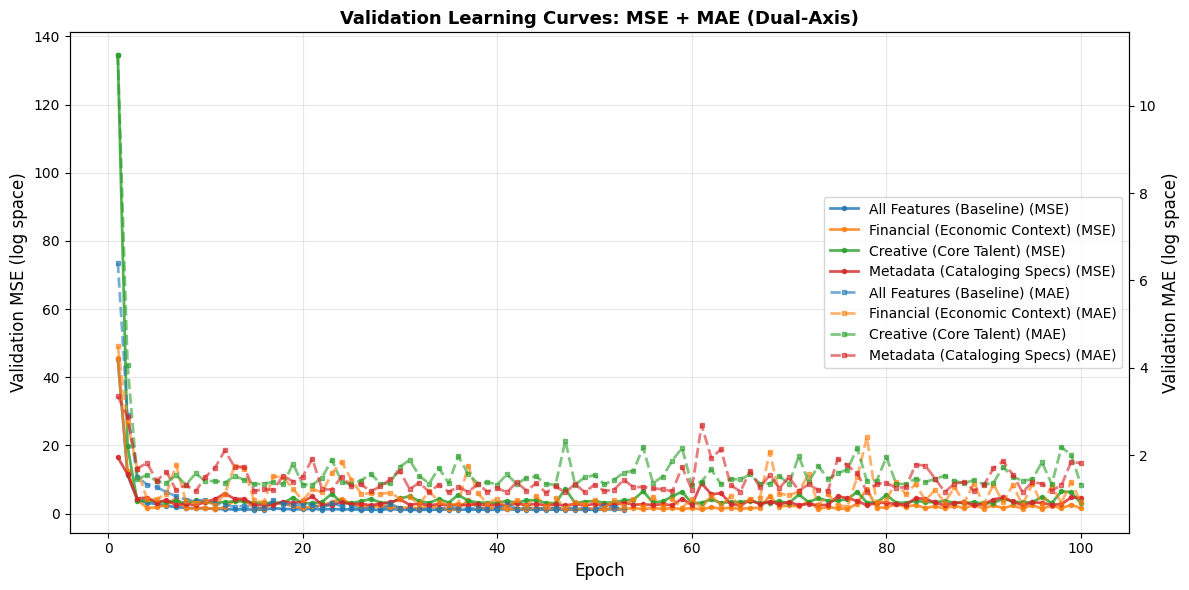

In [47]:
# Plot validation learning curves (MSE + MAE on dual axis)
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

color_idx = 0
plotted = 0

for group_key, model_info in models.items():
    if group_key not in results_history or len(results_history[group_key]["epoch"]) == 0:
        continue  # nothing to plot

    group_history = results_history[group_key]
    epochs = group_history["epoch"]
    c = colors[color_idx % len(colors)]
    color_idx += 1
    plotted += 1

    # MSE on left axis
    ax1.plot(
        epochs, group_history["val_mse"],
        label=f"{model_info['group_name']} (MSE)",
        color=c, linestyle="-", linewidth=2, marker="o", markersize=3, alpha=0.8
    )

    # MAE on right axis (dashed)
    ax2.plot(
        epochs, group_history["val_mae"],
        label=f"{model_info['group_name']} (MAE)",
        color=c, linestyle="--", linewidth=2, marker="s", markersize=3, alpha=0.6
    )

ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Validation MSE (log space)", fontsize=12)
ax2.set_ylabel("Validation MAE (log space)", fontsize=12)
ax1.set_title("Validation Learning Curves: MSE + MAE (Dual-Axis)", fontsize=13, fontweight="bold")
ax1.grid(True, alpha=0.3)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=10)

plt.tight_layout()

if plotted > 0:
    plot_path = PLOTS_DIR / "validation_learning_curves_dual_axis.png"
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    print(f"Validation learning curves saved to {plot_path}")
else:
    print("No histories found to plot.")

plt.show()


Training learning curves saved to c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\plots\training_learning_curves_dual_axis.png


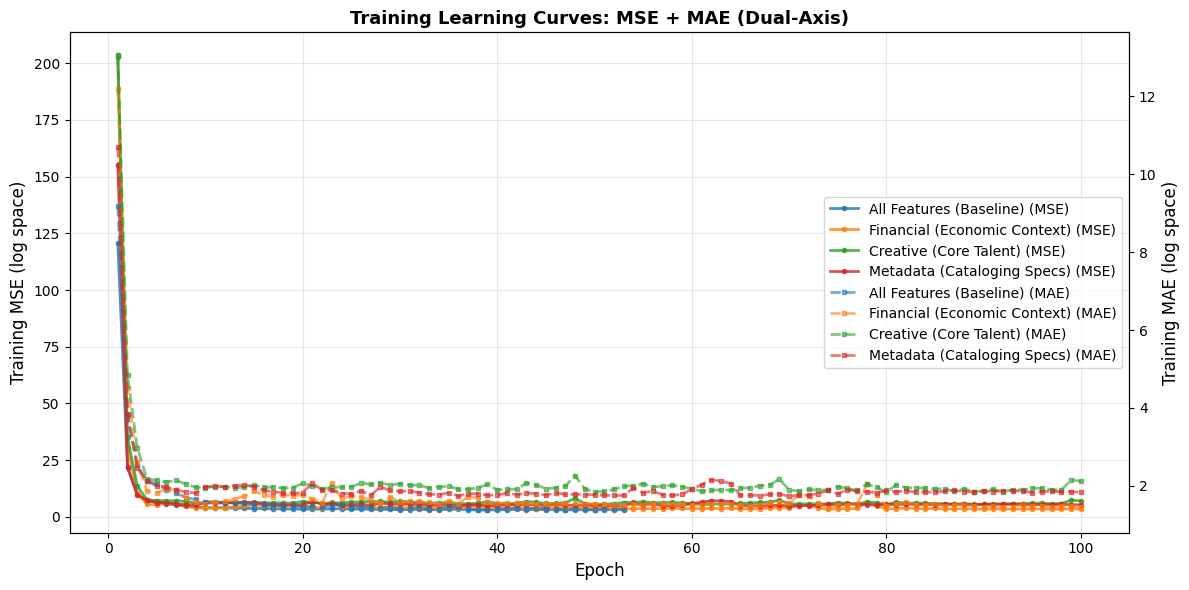

In [48]:
# Plot training learning curves
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
color_idx = 0
plotted = 0

for group_key, model_info in models.items():
    if group_key not in results_history or len(results_history[group_key]["epoch"]) == 0:
        continue

    group_history = results_history[group_key]
    epochs = group_history["epoch"]
    c = colors[color_idx % len(colors)]
    color_idx += 1
    plotted += 1

    # MSE on left axis
    ax1.plot(
        epochs, group_history["train_mse"],
        label=f"{model_info['group_name']} (MSE)",
        color=c, linestyle="-", linewidth=2, marker="o", markersize=3, alpha=0.8
    )

    # MAE on right axis (dashed)
    ax2.plot(
        epochs, group_history["train_mae"],
        label=f"{model_info['group_name']} (MAE)",
        color=c, linestyle="--", linewidth=2, marker="s", markersize=3, alpha=0.6
    )

ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Training MSE (log space)", fontsize=12)
ax2.set_ylabel("Training MAE (log space)", fontsize=12)
ax1.set_title("Training Learning Curves: MSE + MAE (Dual-Axis)", fontsize=13, fontweight="bold")
ax1.grid(True, alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right", fontsize=10)

plt.tight_layout()

if plotted > 0:
    plot_path = PLOTS_DIR / "training_learning_curves_dual_axis.png"
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    print(f"Training learning curves saved to {plot_path}")
else:
    print("No histories found to plot.")

plt.show()


## Results aggregation
Summarize model performance, compute deltas vs baseline, and persist results for reporting.

In [49]:
# Generate summary table
summary_rows = []

baseline_best_mse = None

for group_key, model_info in models.items():
    group_history = results_history[group_key]
    
    # Skip models without validation history
    if len(group_history["val_mse"]) == 0:
        print(f"Skipping {model_info['group_name']} (no validation history). Run training first.")
        continue
    
    # Get best and final metrics
    best_mse_idx = np.argmin(group_history["val_mse"])
    best_mse = group_history["val_mse"][best_mse_idx]
    best_mae = group_history["val_mae"][best_mse_idx]
    
    final_mse = group_history["val_mse"][-1]
    final_mae = group_history["val_mae"][-1]
    
    # Parameter count
    n_params = count_params(model_info["model"])
    
    # Average training time
    avg_time_per_epoch = np.mean(group_history["epoch_time"]) if len(group_history["epoch_time"]) > 0 else 0.0
    
    # Store baseline best MSE for delta calculation
    if group_key == "baseline":
        baseline_best_mse = best_mse
    
    summary_rows.append({
        "Model": model_info["group_name"],
        "Best Val MSE": best_mse,
        "Best Val MAE": best_mae,
        "Final Val MSE": final_mse,
        "Final Val MAE": final_mae,
        "Trainable Parameters": n_params,
        "Avg Time/Epoch (s)": avg_time_per_epoch,
        "Input Dim": model_info["input_dim"],
    })

# Fallback: build baseline row from baseline_history_df if baseline history was skipped
if baseline_best_mse is None and "baseline_history_df" in globals():
    baseline_columns = set(baseline_history_df.columns)
    def pick_col(options):
        for col in options:
            if col in baseline_columns:
                return col
        return None
    
    train_mse_col = pick_col(["train_mse", "train_loss", "train_mse_loss"])
    val_mse_col = pick_col(["val_mse", "val_loss", "val_mse_loss"])
    train_mae_col = pick_col(["train_mae", "train_mae_loss", "train_mae_metric"])
    val_mae_col = pick_col(["val_mae", "val_mae_loss", "val_mae_metric"])
    epoch_time_col = pick_col(["epoch_time", "time", "epoch_seconds"])
    
    if all([train_mse_col, val_mse_col, train_mae_col, val_mae_col]):
        best_mse_idx = int(np.argmin(baseline_history_df[val_mse_col].values))
        best_mse = float(baseline_history_df[val_mse_col].values[best_mse_idx])
        best_mae = float(baseline_history_df[val_mae_col].values[best_mse_idx])
        final_mse = float(baseline_history_df[val_mse_col].values[-1])
        final_mae = float(baseline_history_df[val_mae_col].values[-1])
        avg_time_per_epoch = float(np.mean(baseline_history_df[epoch_time_col].values)) if epoch_time_col else 0.0
        baseline_best_mse = best_mse
        baseline_row = {
            "Model": FEATURE_GROUPS["baseline"]["name"],
            "Best Val MSE": best_mse,
            "Best Val MAE": best_mae,
            "Final Val MSE": final_mse,
            "Final Val MAE": final_mae,
            "Trainable Parameters": count_params(models["baseline"]["model"]),
            "Avg Time/Epoch (s)": avg_time_per_epoch,
            "Input Dim": models["baseline"]["input_dim"],
        }
        summary_rows.insert(0, baseline_row)
    else:
        print("Baseline history missing required columns; cannot compute delta vs baseline.")

summary_df = pd.DataFrame(summary_rows)

# Calculate delta from baseline
if baseline_best_mse is not None:
    summary_df["MSE Delta from Baseline (%)"] = (
        (summary_df["Best Val MSE"] - baseline_best_mse) / baseline_best_mse * 100
    )

# Save summary table
summary_path = SUMMARIES_DIR / "model_comparison_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("\n" + "="*100)
print("MODEL PERFORMANCE SUMMARY")
print("="*100)
print(summary_df.to_string(index=False))
print("="*100)
print(f"\nSummary table saved to {summary_path}")


MODEL PERFORMANCE SUMMARY
                       Model  Best Val MSE  Best Val MAE  Final Val MSE  Final Val MAE  Trainable Parameters  Avg Time/Epoch (s)  Input Dim  MSE Delta from Baseline (%)
     All Features (Baseline)      1.063199      0.750369       1.202952       0.816089                179201            0.000000         12                     0.000000
Financial (Economic Context)      1.252817      0.798052       1.562822       0.924237                175105            0.401202          4                    17.834621
      Creative (Core Talent)      3.016654      1.318856       3.042511       1.325451                175105            0.813463          4                   183.733661
 Metadata (Cataloging Specs)      2.352881      1.146593       4.602179       1.819601                175105            1.223375          4                   121.301974

Summary table saved to c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding

In [50]:
# Generate summary table
summary_rows = []
baseline_best_mse = None

for group_key, model_info in models.items():

    # NEW: safe guard
    if group_key not in results_history:
        print(f"Skipping {model_info['group_name']} (no history found in results_history).")
        continue

    group_history = results_history[group_key]

    # Skip models without validation history
    if len(group_history["val_mse"]) == 0:
        print(f"Skipping {model_info['group_name']} (no validation history). Run training first.")
        continue

    # Get best and final metrics
    best_mse_idx = np.argmin(group_history["val_mse"])
    best_mse = group_history["val_mse"][best_mse_idx]
    best_mae = group_history["val_mae"][best_mse_idx]

    final_mse = group_history["val_mse"][-1]
    final_mae = group_history["val_mae"][-1]

    # Parameter count
    n_params = count_params(model_info["model"])

    # Average training time
    avg_time_per_epoch = np.mean(group_history["epoch_time"]) if len(group_history["epoch_time"]) > 0 else 0.0

    # Store baseline best MSE for delta calculation
    if group_key == "baseline":
        baseline_best_mse = best_mse

    summary_rows.append({
        "Model": model_info["group_name"],
        "Best Val MSE": best_mse,
        "Best Val MAE": best_mae,
        "Final Val MSE": final_mse,
        "Final Val MAE": final_mae,
        "Trainable Parameters": n_params,
        "Avg Time/Epoch (s)": avg_time_per_epoch,
        "Input Dim": model_info["input_dim"],
    })

# Fallback: build baseline row from baseline_history_df if baseline history was skipped
if baseline_best_mse is None and "baseline_history_df" in globals():
    baseline_columns = set(baseline_history_df.columns)
    def pick_col(options):
        for col in options:
            if col in baseline_columns:
                return col
        return None

    train_mse_col = pick_col(["train_mse", "train_loss", "train_mse_loss"])
    val_mse_col = pick_col(["val_mse", "val_loss", "val_mse_loss"])
    train_mae_col = pick_col(["train_mae", "train_mae_loss", "train_mae_metric"])
    val_mae_col = pick_col(["val_mae", "val_mae_loss", "val_mae_metric"])
    epoch_time_col = pick_col(["epoch_time", "time", "epoch_seconds"])

    if all([train_mse_col, val_mse_col, train_mae_col, val_mae_col]):
        best_mse_idx = int(np.argmin(baseline_history_df[val_mse_col].values))
        best_mse = float(baseline_history_df[val_mse_col].values[best_mse_idx])
        best_mae = float(baseline_history_df[val_mae_col].values[best_mse_idx])
        final_mse = float(baseline_history_df[val_mse_col].values[-1])
        final_mae = float(baseline_history_df[val_mae_col].values[-1])
        avg_time_per_epoch = float(np.mean(baseline_history_df[epoch_time_col].values)) if epoch_time_col else 0.0
        baseline_best_mse = best_mse
        baseline_row = {
            "Model": FEATURE_GROUPS["baseline"]["name"],
            "Best Val MSE": best_mse,
            "Best Val MAE": best_mae,
            "Final Val MSE": final_mse,
            "Final Val MAE": final_mae,
            "Trainable Parameters": count_params(models["baseline"]["model"]),
            "Avg Time/Epoch (s)": avg_time_per_epoch,
            "Input Dim": models["baseline"]["input_dim"],
        }
        summary_rows.insert(0, baseline_row)
    else:
        print("Baseline history missing required columns; cannot compute delta vs baseline.")

summary_df = pd.DataFrame(summary_rows)

# Calculate delta from baseline
if baseline_best_mse is not None and len(summary_df) > 0:
    summary_df["MSE Delta from Baseline (%)"] = (
        (summary_df["Best Val MSE"] - baseline_best_mse) / baseline_best_mse * 100
    )

# Save summary table
summary_path = SUMMARIES_DIR / "model_comparison_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("\n" + "="*100)
print("MODEL PERFORMANCE SUMMARY")
print("="*100)
print(summary_df.to_string(index=False))
print("="*100)
print(f"\nSummary table saved to {summary_path}")



MODEL PERFORMANCE SUMMARY
                       Model  Best Val MSE  Best Val MAE  Final Val MSE  Final Val MAE  Trainable Parameters  Avg Time/Epoch (s)  Input Dim  MSE Delta from Baseline (%)
     All Features (Baseline)      1.063199      0.750369       1.202952       0.816089                179201            0.000000         12                     0.000000
Financial (Economic Context)      1.252817      0.798052       1.562822       0.924237                175105            0.401202          4                    17.834621
      Creative (Core Talent)      3.016654      1.318856       3.042511       1.325451                175105            0.813463          4                   183.733661
 Metadata (Cataloging Specs)      2.352881      1.146593       4.602179       1.819601                175105            1.223375          4                   121.301974

Summary table saved to c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding

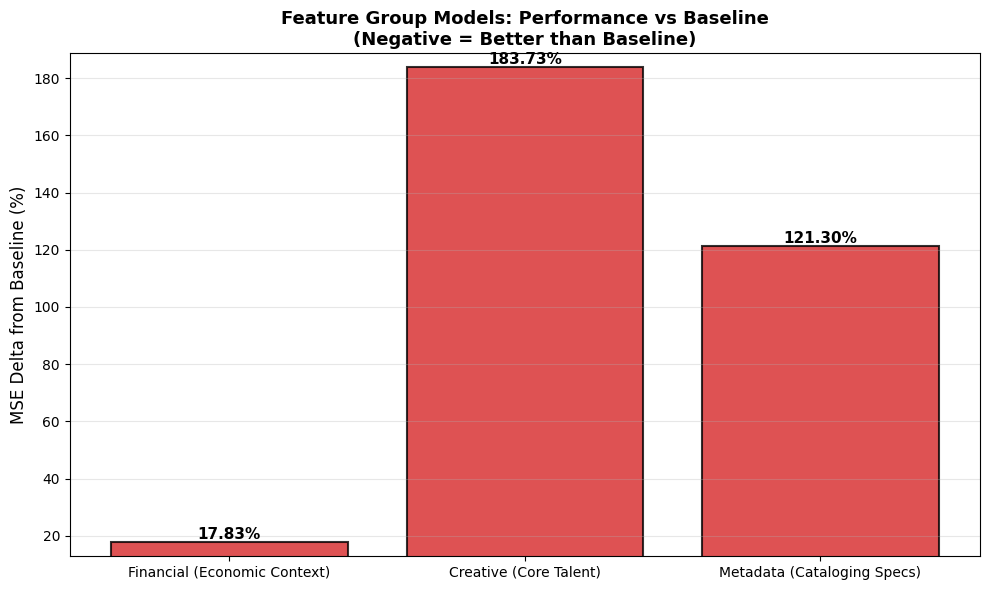

Performance delta plot saved to c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\plots\performance_delta_from_baseline.png


In [51]:
# Plot performance delta from baseline
if summary_df.empty or "MSE Delta from Baseline (%)" not in summary_df.columns:
    print("No delta values available. Run results aggregation first.")
else:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Get models excluding baseline
    group_names = [name for name in summary_df["Model"] if name != "All Features (Baseline)"]
    deltas = summary_df[summary_df["Model"] != "All Features (Baseline)"]["MSE Delta from Baseline (%)"].values

    if len(deltas) == 0:
        print("No non-baseline models to plot.")
    else:
        colors_bar = ["#2ca02c" if d < 0 else "#d62728" for d in deltas]

        bars = ax.bar(group_names, deltas, color=colors_bar, alpha=0.8, edgecolor="black", linewidth=1.5)

        # Add value labels on bars
        for bar, delta in zip(bars, deltas):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f"{delta:.2f}%",
                    ha="center", va="bottom" if height > 0 else "top", fontsize=11, fontweight="bold")

        ax.axhline(y=0, color="black", linestyle="-", linewidth=1.5, label="Baseline")
        ax.set_ylabel("MSE Delta from Baseline (%)", fontsize=12)
        ax.set_title("Feature Group Models: Performance vs Baseline\n(Negative = Better than Baseline)", 
                    fontsize=13, fontweight="bold")
        ax.grid(True, axis="y", alpha=0.3)
        ax.set_ylim(bottom=min(deltas) - 5, top=max(deltas) + 5)

        plt.tight_layout()
        plot_path = PLOTS_DIR / "performance_delta_from_baseline.png"
        plt.savefig(plot_path, dpi=150, bbox_inches="tight")
        plt.show()

        print(f"Performance delta plot saved to {plot_path}")

## Training history export
Persist per-epoch metrics for reproducibility and later analysis.

In [52]:
# Convert history to DataFrames and save
for group_key, group_history in results_history.items():
    # Create DataFrame from history
    hist_df = pd.DataFrame(group_history)
    
    # Save CSV
    csv_path = HISTORIES_DIR / f"training_history_{group_key}.csv"
    hist_df.to_csv(csv_path, index=False)
    
    # Save NPY (numpy archive)
    npy_path = HISTORIES_DIR / f"training_history_{group_key}.npy"
    np.save(npy_path, group_history)

# Save combined JSON (human-readable summary)
combined_history = {}
for group_key, group_history in results_history.items():
    group_name = FEATURE_GROUPS[group_key]["name"]
    combined_history[group_name] = {
        k: [float(v) if isinstance(v, (np.floating, np.integer)) else v for v in val]
        for k, val in group_history.items()
    }

json_path = HISTORIES_DIR / "all_training_histories.json"
with open(json_path, "w") as f:
    json.dump(combined_history, f, indent=2)

print(f"Training histories saved:")
for group_key in results_history.keys():
    print(f"  - {HISTORIES_DIR / f'training_history_{group_key}.csv'}")
print(f"  - {json_path}")

Training histories saved:
  - c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\training_histories\training_history_baseline.csv
  - c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\training_histories\training_history_financial.csv
  - c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\training_histories\training_history_creative.csv
  - c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\training_histories\training_history_metadata.csv
  - c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\training_histories\all_training_histories.json


## Ensemble variants
Start with a simple average of feature-group predictions as a baseline ensemble; then explore weighted variants below.


In [53]:
# Collect validation predictions for all models (baseline + feature groups)
all_val_predictions = {}

with torch.no_grad():
    for group_key, model_info in models.items():
        model = model_info["model"]
        model.eval()

        val_loader = data_loaders[group_key]["val_loader"]

        preds = []
        targets = []

        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            out = model(xb).squeeze(-1)

            preds.append(out.cpu().numpy())
            targets.append(yb.cpu().numpy())

        all_val_predictions[group_key] = np.concatenate(preds)
        all_val_predictions["actual"] = np.concatenate(targets)

# Sanity print
print("Collected validation predictions for:")
for k, v in all_val_predictions.items():
    print(f"  {k}: shape = {v.shape}")


Collected validation predictions for:
  baseline: shape = (815,)
  actual: shape = (815,)
  financial: shape = (815,)
  creative: shape = (815,)
  metadata: shape = (815,)


In [54]:
# Baseline vs Feature Group Average Ensemble - Validation Score Comparison
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate average predictions from the three feature groups (excluding baseline)
financial_pred = all_val_predictions["financial"]
creative_pred = all_val_predictions["creative"]
metadata_pred = all_val_predictions["metadata"]
baseline_pred = all_val_predictions["baseline"]
actual_pred = all_val_predictions["actual"]

# Simple average of the three feature groups
avg_ensemble_pred = (financial_pred + creative_pred + metadata_pred) / 3

# Validation metrics (MSE & MAE)
baseline_val_mse = mean_squared_error(actual_pred, baseline_pred)
baseline_val_mae = mean_absolute_error(actual_pred, baseline_pred)

ensemble_val_mse = mean_squared_error(actual_pred, avg_ensemble_pred)
ensemble_val_mae = mean_absolute_error(actual_pred, avg_ensemble_pred)

# Print validation comparison
print("\n" + "="*90)
print("BASELINE vs FEATURE GROUP AVERAGE ENSEMBLE - VALIDATION PERFORMANCE")
print("="*90)
print(f"\nEnsemble Method: Simple Average of (Financial + Creative + Metadata) / 3\n")

print(f"{'Metric':<15} {'Baseline':<18} {'Ensemble':<18} {'Delta (%)':<15}")
print("-" * 70)
val_mse_delta = ((ensemble_val_mse - baseline_val_mse) / baseline_val_mse) * 100
val_mae_delta = ((ensemble_val_mae - baseline_val_mae) / baseline_val_mae) * 100
print(f"{'Validation MSE':<15} {baseline_val_mse:<18.4f} {ensemble_val_mse:<18.4f} {val_mse_delta:+.2f}%")
print(f"{'Validation MAE':<15} {baseline_val_mae:<18.4f} {ensemble_val_mae:<18.4f} {val_mae_delta:+.2f}%")

print("-" * 90)
if ensemble_val_mse < baseline_val_mse:
    improvement = ((baseline_val_mse - ensemble_val_mse) / baseline_val_mse) * 100
    print(f"✓ Ensemble IMPROVES over Baseline by {improvement:.2f}% on Validation MSE")
else:
    degradation = ((ensemble_val_mse - baseline_val_mse) / baseline_val_mse) * 100
    print(f"✗ Ensemble DEGRADES vs Baseline by {degradation:.2f}% on Validation MSE")
print("="*90)



BASELINE vs FEATURE GROUP AVERAGE ENSEMBLE - VALIDATION PERFORMANCE

Ensemble Method: Simple Average of (Financial + Creative + Metadata) / 3

Metric          Baseline           Ensemble           Delta (%)      
----------------------------------------------------------------------
Validation MSE  1.0059             1.6483             +63.86%
Validation MAE  0.7176             0.9361             +30.46%
------------------------------------------------------------------------------------------
✗ Ensemble DEGRADES vs Baseline by 63.86% on Validation MSE


## Ensemble variants: calculated weights
Derive performance-based weights from earlier deltas and evaluate the weighted ensemble on validation data.


In [55]:
# Calculate performance-based weights from Section 9 summary
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Extract deltas from summary_df for feature groups only (excluding baseline)
baseline_name = FEATURE_GROUPS["baseline"]["name"]
feature_groups_summary = summary_df[summary_df["Model"] != baseline_name].copy()

# Get the performance deltas (negative = better, positive = worse)
delta_map = dict(
    zip(feature_groups_summary["Model"], feature_groups_summary["MSE Delta from Baseline (%)"])
)

financial_delta = delta_map[FEATURE_GROUPS["financial"]["name"]]
creative_delta  = delta_map[FEATURE_GROUPS["creative"]["name"]]
metadata_delta  = delta_map[FEATURE_GROUPS["metadata"]["name"]]


# Convert deltas to performance scores using exponential decay
# Higher delta (worse performance) gets exponentially lower weight
# Formula: weight ∝ exp(-delta / 100)
deltas = np.array([financial_delta, creative_delta, metadata_delta])

# Apply exponential decay: exp(-delta/100)
# This keeps all weights positive even for large positive deltas
performance_scores = np.exp(-deltas / 100)

# Normalize to weights (sum to 1)
calculated_weights = performance_scores / performance_scores.sum()

print("\n" + "="*90)
print("SECTION 12: CALCULATED WEIGHTED ENSEMBLE (EXPONENTIAL DECAY WEIGHTS)")
print("="*90)
print(f"\nPerformance Deltas from Section 9 (MSE vs Baseline):")
print(f"  Financial: {financial_delta:+.2f}%")
print(f"  Creative:  {creative_delta:+.2f}%")
print(f"  Metadata:  {metadata_delta:+.2f}%")

print(f"\nExponential Decay Scores (exp(-delta/100)):")
print(f"  Financial: {performance_scores[0]:.6f}")
print(f"  Creative:  {performance_scores[1]:.6f}")
print(f"  Metadata:  {performance_scores[2]:.6f}")

print(f"\nCalculated Weights (normalized to sum=1):")
print(f"  Financial: {calculated_weights[0]:.4f}")
print(f"  Creative:  {calculated_weights[1]:.4f}")
print(f"  Metadata:  {calculated_weights[2]:.4f}")
print(f"  Sum:       {calculated_weights.sum():.4f}")

# Apply calculated weights to get ensemble predictions
financial_pred_val = all_val_predictions["financial"]
creative_pred_val = all_val_predictions["creative"]
metadata_pred_val = all_val_predictions["metadata"]
baseline_pred_val = all_val_predictions["baseline"]
actual_val = all_val_predictions["actual"]

calculated_weighted_ensemble_pred = (
    calculated_weights[0] * financial_pred_val +
    calculated_weights[1] * creative_pred_val +
    calculated_weights[2] * metadata_pred_val
)

# Calculate metrics
baseline_val_mse = mean_squared_error(actual_val, baseline_pred_val)
baseline_val_mae = mean_absolute_error(actual_val, baseline_pred_val)

calc_weighted_val_mse = mean_squared_error(actual_val, calculated_weighted_ensemble_pred)
calc_weighted_val_mae = mean_absolute_error(actual_val, calculated_weighted_ensemble_pred)

# Compare
print(f"\nValidation Performance Comparison:")
print(f"{'Metric':<15} {'Baseline':<18} {'Calc Weighted':<18} {'Delta (%)':<15}")
print("-" * 70)
calc_mse_delta = ((calc_weighted_val_mse - baseline_val_mse) / baseline_val_mse) * 100
calc_mae_delta = ((calc_weighted_val_mae - baseline_val_mae) / baseline_val_mae) * 100
print(f"{'Validation MSE':<15} {baseline_val_mse:<18.4f} {calc_weighted_val_mse:<18.4f} {calc_mse_delta:+.2f}%")
print(f"{'Validation MAE':<15} {baseline_val_mae:<18.4f} {calc_weighted_val_mae:<18.4f} {calc_mae_delta:+.2f}%")

print("-" * 90)
if calc_weighted_val_mse < baseline_val_mse:
    improvement = ((baseline_val_mse - calc_weighted_val_mse) / baseline_val_mse) * 100
    print(f"✓ Calculated Weighted Ensemble IMPROVES over Baseline by {improvement:.2f}%")
else:
    degradation = ((calc_weighted_val_mse - baseline_val_mse) / baseline_val_mse) * 100
    print(f"✗ Calculated Weighted Ensemble DEGRADES vs Baseline by {degradation:.2f}%")
print("="*90)



SECTION 12: CALCULATED WEIGHTED ENSEMBLE (EXPONENTIAL DECAY WEIGHTS)

Performance Deltas from Section 9 (MSE vs Baseline):
  Financial: +17.83%
  Creative:  +183.73%
  Metadata:  +121.30%

Exponential Decay Scores (exp(-delta/100)):
  Financial: 0.836653
  Creative:  0.159241
  Metadata:  0.297298

Calculated Weights (normalized to sum=1):
  Financial: 0.6470
  Creative:  0.1231
  Metadata:  0.2299
  Sum:       1.0000

Validation Performance Comparison:
Metric          Baseline           Calc Weighted      Delta (%)      
----------------------------------------------------------------------
Validation MSE  1.0059             1.2801             +27.26%
Validation MAE  0.7176             0.8050             +12.18%
------------------------------------------------------------------------------------------
✗ Calculated Weighted Ensemble DEGRADES vs Baseline by 27.26%


## Ensemble variants: learned weights (frozen models)
Learn softmax-normalized weights over frozen model predictions using validation loss.

In [56]:
# =========================
# SECTION 13
# =========================
print("\n" + "="*90)
print("SECTION 13: LEARNED WEIGHTED ENSEMBLE (SOFTMAX-NORMALIZED FUSION NEURON)")
print("="*90)

import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ------------------------------------------------------------------
# NOTE:
# This neuron is trained ONLY to learn fusion weights.
# Its validation loss MUST NOT be compared to other validation scores.
# Final evaluation will happen on TEST only (later).
# ------------------------------------------------------------------

# Prepare validation tensors (predictions are already frozen outputs)
financial_val_tensor = torch.tensor(financial_pred_val, dtype=torch.float32, device=device).unsqueeze(1)
creative_val_tensor  = torch.tensor(creative_pred_val,  dtype=torch.float32, device=device).unsqueeze(1)
metadata_val_tensor  = torch.tensor(metadata_pred_val,  dtype=torch.float32, device=device).unsqueeze(1)
actual_val_tensor    = torch.tensor(actual_val,          dtype=torch.float32, device=device).view(-1)

X_ensemble_val = torch.cat(
    [financial_val_tensor, creative_val_tensor, metadata_val_tensor], dim=1
)  # (N, 3)

# ------------------------------------------------------------------
# Fusion neuron: single trainable softmax-normalized weight vector
# ------------------------------------------------------------------
class SoftmaxWeightedEnsemble(nn.Module):
    def __init__(self):
        super().__init__()
        self.raw_weights = nn.Parameter(torch.randn(3))

    def forward(self, x):
        w = torch.softmax(self.raw_weights, dim=0)  # (3,)
        return torch.sum(x * w, dim=1)               # (N,)

neuron_model = SoftmaxWeightedEnsemble().to(device)

optimizer = optim.AdamW(neuron_model.parameters(), lr=1e-2, weight_decay=1e-5)
criterion = nn.MSELoss()

num_epochs_neuron = 100
neuron_losses = []

# ------------------------------------------------------------------
# Train ONLY the fusion neuron
# ------------------------------------------------------------------
for epoch in range(num_epochs_neuron):
    neuron_model.train()
    optimizer.zero_grad(set_to_none=True)

    pred = neuron_model(X_ensemble_val)
    loss = criterion(pred, actual_val_tensor)

    loss.backward()
    optimizer.step()

    neuron_losses.append(loss.item())

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{num_epochs_neuron} | mse = {loss.item():.6f}")

# ------------------------------------------------------------------
# Extract learned weights (this is the REAL output of this section)
# ------------------------------------------------------------------
with torch.no_grad():
    learned_weights = torch.softmax(neuron_model.raw_weights, dim=0).cpu().numpy()

print("\nLearned Fusion Weights (softmax, sum=1):")
print(f"  Financial: {learned_weights[0]:.4f}")
print(f"  Creative:  {learned_weights[1]:.4f}")
print(f"  Metadata:  {learned_weights[2]:.4f}")
print(f"  Sum:       {learned_weights.sum():.4f}")

print("\nNOTE:")
print("These weights will be applied to TEST predictions later.")
print("Validation loss here is used ONLY to learn the fusion parameters.")



SECTION 13: LEARNED WEIGHTED ENSEMBLE (SOFTMAX-NORMALIZED FUSION NEURON)
Epoch  20/100 | mse = 1.462597
Epoch  40/100 | mse = 1.362651
Epoch  60/100 | mse = 1.299828
Epoch  80/100 | mse = 1.265067
Epoch 100/100 | mse = 1.246526

Learned Fusion Weights (softmax, sum=1):
  Financial: 0.7299
  Creative:  0.1289
  Metadata:  0.1412
  Sum:       1.0000

NOTE:
These weights will be applied to TEST predictions later.
Validation loss here is used ONLY to learn the fusion parameters.


## Ensemble variants: joint training
Train the group models and the ensemble neuron together to observe adaptive weighting over epochs.

In [68]:
# =========================
# SECTION 14
# =========================
print("\n" + "="*100)
print("SECTION 14: JOINT TRAINING (MODELS + ENSEMBLE NEURON TOGETHER)")
print("="*100)

import torch
import torch.nn as nn
import torch.optim as optim
import time
from pathlib import Path
import json

# ------------------------------------------------------------
# 1) Reinitialize models (fresh start)
# ------------------------------------------------------------
joint_models = {}
for group_key in ["financial", "creative", "metadata"]:
    loader_info = data_loaders[group_key]
    input_dim = loader_info["input_dim"]  # must be 4

    model = TabularRegressor(
        mode="shared",
        input_dim=input_dim,
        encoder_hidden=BASELINE_ENCODER_HIDDEN,
        head_hidden=BASELINE_HEAD_HIDDEN,
        dropout=BASELINE_DROPOUT,
    ).to(device)

    joint_models[group_key] = {"model": model}

# ------------------------------------------------------------
# 2) Fusion neuron
# ------------------------------------------------------------
class SoftmaxWeightedEnsemble(nn.Module):
    def __init__(self):
        super().__init__()
        self.raw_weights = nn.Parameter(torch.randn(3))

    def forward(self, x):
        w = torch.softmax(self.raw_weights, dim=0)
        return torch.sum(x * w, dim=1)

joint_neuron_model = SoftmaxWeightedEnsemble().to(device)

# ------------------------------------------------------------
# 3) Optimizer (all params)
# ------------------------------------------------------------
JOINT_EPOCHS = 100
criterion = nn.MSELoss()

param_groups = [
    {"params": joint_models["financial"]["model"].parameters(), "lr": LEARNING_RATE},
    {"params": joint_models["creative"]["model"].parameters(),  "lr": LEARNING_RATE},
    {"params": joint_models["metadata"]["model"].parameters(),  "lr": LEARNING_RATE},
    {"params": joint_neuron_model.parameters(),                 "lr": 1e-3},
]

joint_optimizer = optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)

# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------
def forward_ensemble_batch(Xf, Xc, Xm):
    pf = joint_models["financial"]["model"](Xf).squeeze()
    pc = joint_models["creative"]["model"](Xc).squeeze()
    pm = joint_models["metadata"]["model"](Xm).squeeze()
    return joint_neuron_model(torch.stack([pf, pc, pm], dim=1))

# ------------------------------------------------------------
# IMPORTANT FIX: rebuild loaders with shuffle=False
# ------------------------------------------------------------
train_loaders = {}
val_loaders = {}

for g in ["financial", "creative", "metadata"]:
    base_train = data_loaders[g]["train_loader"]
    base_val   = data_loaders[g]["val_loader"]

    train_loaders[g] = torch.utils.data.DataLoader(
        base_train.dataset,
        batch_size=base_train.batch_size,
        shuffle=False,
        num_workers=base_train.num_workers,
        pin_memory=True,
    )

    val_loaders[g] = torch.utils.data.DataLoader(
        base_val.dataset,
        batch_size=base_val.batch_size,
        shuffle=False,
        num_workers=base_val.num_workers,
        pin_memory=True,
    )

# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------
best_val_mse = float("inf")
last_val_mse = None
last_val_mae = None

for epoch in range(1, JOINT_EPOCHS + 1):
    t0 = time.time()

    joint_neuron_model.train()
    for g in joint_models:
        joint_models[g]["model"].train()

    # ---- TRAIN ----
    train_loss = 0.0
    n = 0

    for (Xf, yf), (Xc, yc), (Xm, ym) in zip(
        train_loaders["financial"],
        train_loaders["creative"],
        train_loaders["metadata"],
    ):
        Xf, Xc, Xm = Xf.to(device), Xc.to(device), Xm.to(device)
        y = yf.to(device).float()

        joint_optimizer.zero_grad(set_to_none=True)
        y_hat = forward_ensemble_batch(Xf, Xc, Xm)
        loss = criterion(y_hat, y)
        loss.backward()
        joint_optimizer.step()

        train_loss += loss.item() * y.size(0)
        n += y.size(0)

    # ---- VALIDATION ----
    joint_neuron_model.eval()
    for g in joint_models:
        joint_models[g]["model"].eval()

    preds, targets = [], []

    with torch.no_grad():
        for (Xf, yf), (Xc, yc), (Xm, ym) in zip(
            val_loaders["financial"],
            val_loaders["creative"],
            val_loaders["metadata"],
        ):
            Xf, Xc, Xm = Xf.to(device), Xc.to(device), Xm.to(device)
            y = yf.to(device).float()

            preds.append(forward_ensemble_batch(Xf, Xc, Xm))
            targets.append(y)

        y_hat = torch.cat(preds)
        y_val = torch.cat(targets)

        val_mse = torch.mean((y_hat - y_val) ** 2).item()
        val_mae = torch.mean(torch.abs(y_hat - y_val)).item()
        w = torch.softmax(joint_neuron_model.raw_weights, dim=0).cpu().numpy()

    last_val_mse = val_mse
    last_val_mae = val_mae

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:3d} | "
            f"train_loss={train_loss/n:.6f} | "
            f"val_mse={val_mse:.6f} | "
            f"w=[{w[0]:.3f},{w[1]:.3f},{w[2]:.3f}] | "
            f"time={time.time()-t0:.1f}s"
        )

# ------------------------------------------------------------
# Save weights + metrics for later sections
# ------------------------------------------------------------
with torch.no_grad():
    joint_learned_weights = torch.softmax(joint_neuron_model.raw_weights, dim=0).cpu().numpy()

joint_ensemble_mse = float(last_val_mse) if last_val_mse is not None else None
joint_ensemble_mae = float(last_val_mae) if last_val_mae is not None else None

print("\nJoint learned weights (Sec 14):")
print(f"  Financial: {joint_learned_weights[0]:.4f}")
print(f"  Creative:  {joint_learned_weights[1]:.4f}")
print(f"  Metadata:  {joint_learned_weights[2]:.4f}")

# Persist checkpoint + summary
section14_dir = Path(CHECKPOINTS_DIR) / "section14_joint_ensemble"
section14_dir.mkdir(parents=True, exist_ok=True)
ckpt_path = section14_dir / "joint_ensemble_ckpt.pt"

torch.save(
    {
        "joint_models": {g: joint_models[g]["model"].state_dict() for g in joint_models},
        "joint_neuron": joint_neuron_model.state_dict(),
        "joint_learned_weights": joint_learned_weights.tolist(),
        "val_mse": joint_ensemble_mse,
        "val_mae": joint_ensemble_mae,
    },
    ckpt_path,
)

summary_path = Path(SUMMARIES_DIR) / "section14_joint_ensemble_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(
        {
            "joint_learned_weights": joint_learned_weights.tolist(),
            "val_mse": joint_ensemble_mse,
            "val_mae": joint_ensemble_mae,
            "epochs": JOINT_EPOCHS,
        },
        f,
        indent=2,
    )

print(f"\n✓ Saved Section 14 checkpoint to: {ckpt_path}")
print(f"✓ Saved Section 14 summary to: {summary_path}")
print("\n✓ Joint training completed successfully.")


SECTION 14: JOINT TRAINING (MODELS + ENSEMBLE NEURON TOGETHER)


c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch   1 | train_loss=120.985175 | val_mse=42.929443 | w=[0.102,0.273,0.625] | time=0.6s
Epoch  10 | train_loss=2.308370 | val_mse=1.153738 | w=[0.102,0.275,0.622] | time=0.4s
Epoch  20 | train_loss=1.917539 | val_mse=1.070841 | w=[0.103,0.275,0.623] | time=0.6s
Epoch  30 | train_loss=1.902423 | val_mse=1.060039 | w=[0.103,0.274,0.623] | time=0.6s
Epoch  40 | train_loss=1.862565 | val_mse=1.116898 | w=[0.103,0.274,0.623] | time=1.3s
Epoch  50 | train_loss=1.817082 | val_mse=1.120769 | w=[0.102,0.274,0.624] | time=1.9s
Epoch  60 | train_loss=1.792397 | val_mse=1.166109 | w=[0.102,0.274,0.624] | time=1.3s
Epoch  70 | train_loss=1.805951 | val_mse=1.523772 | w=[0.102,0.274,0.624] | time=1.6s
Epoch  80 | train_loss=1.786713 | val_mse=1.071292 | w=[0.102,0.274,0.625] | time=1.6s
Epoch  90 | train_loss=1.781386 | val_mse=1.076785 | w=[0.102,0.273,0.625] | time=0.6s
Epoch 100 | train_loss=1.758736 | val_mse=1.062809 | w=[0.102,0.273,0.625] | time=0.5s

Joint learned weights (Sec 14):
  Finan

## Fusion experiments: frozen encoders
Freeze group encoders, concatenate their 64-d representations, and train a fusion head on top.


In [58]:
# =========================
# SECTION 15
# =========================
# FUSION AFTER 64 (FROZEN GROUP ENCODERS)
#
# Goal:
# - Use the trained group models (financial/creative/metadata).
# - Extract the 64-d encoder output from each group.
# - Concatenate -> 192-d.
# - Train ONLY a small fusion head (192 -> 1).
# - Encoders are frozen (no gradients).
# - Evaluate on VALIDATION ONLY (no test).

print("\n" + "="*100)
print("SECTION 15: FUSION AFTER 64 (FROZEN GROUP ENCODERS)")
print("="*100)

import torch
import torch.nn as nn
import torch.optim as optim

# ----------------------------
# 0) Required vars check
# ----------------------------
required_vars = ["models", "data_loaders", "device"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}. Run earlier sections first.")

FUSION_GROUPS = ["financial", "creative", "metadata"]

for g in FUSION_GROUPS:
    if g not in models or g not in data_loaders:
        raise RuntimeError(f"Missing '{g}' in models/data_loaders. موجود?")

# ----------------------------
# 1) Freeze encoders (use current trained models as encoders)
# ----------------------------
encoders = {}
for g in FUSION_GROUPS:
    m = models[g]["model"].to(device)
    m.eval()  # stable encoder outputs (no dropout noise)

    if not hasattr(m, "encoder"):
        raise RuntimeError(f"models['{g}']['model'] has no attribute .encoder (required for fusion-after-64).")

    # freeze encoder params
    for p in m.encoder.parameters():
        p.requires_grad = False

    encoders[g] = m.encoder

print(f"✓ Frozen encoders for: {FUSION_GROUPS}")

# Sanity: input dims should be 4 (as you said)
for g in FUSION_GROUPS:
    in_dim = data_loaders[g]["input_dim"]
    print(f"  {g}: input_dim = {in_dim}")
    if in_dim != 4:
        print(f"  ⚠️ WARNING: {g} input_dim is {in_dim}, expected 4 (check your slicing/loader).")

# ----------------------------
# 2) Fusion head (192 -> 1)
# ----------------------------
class FusionHead(nn.Module):
    def __init__(self, in_dim=192):
        super().__init__()
        self.fc = nn.Linear(in_dim, 1)

    def forward(self, x):
        return self.fc(x)

fusion_head = FusionHead(in_dim=64 * 3).to(device)
criterion_fusion = nn.MSELoss()
optimizer_fusion = optim.AdamW(fusion_head.parameters(), lr=1e-3, weight_decay=0.0)

FUSION_EPOCHS = 100
print("✓ Fusion head: 192 -> 1 (linear)")
print(f"✓ Fusion epochs: {FUSION_EPOCHS}")

# ----------------------------
# 3) IMPORTANT: aligned loaders for zip()
#    Rebuild TRAIN/VAL loaders with shuffle=False (otherwise mismatch)
# ----------------------------
train_loaders = {}
val_loaders = {}

for g in FUSION_GROUPS:
    base_train = data_loaders[g]["train_loader"]
    base_val   = data_loaders[g]["val_loader"]

    train_loaders[g] = torch.utils.data.DataLoader(
        base_train.dataset,
        batch_size=base_train.batch_size,
        shuffle=False,
        num_workers=getattr(base_train, "num_workers", 0),
        pin_memory=True,
    )
    val_loaders[g] = torch.utils.data.DataLoader(
        base_val.dataset,
        batch_size=base_val.batch_size,
        shuffle=False,
        num_workers=getattr(base_val, "num_workers", 0),
        pin_memory=True,
    )

print("✓ Rebuilt train/val loaders with shuffle=False for aligned zipping")

# ----------------------------
# 4) Eval on validation (loader-based, no val_tensors_by_group needed)
# ----------------------------
@torch.no_grad()
def eval_fusion_val():
    fusion_head.eval()
    # encoders already eval + frozen

    preds = []
    targets = []

    for (Xf, yf), (Xc, yc), (Xm, ym) in zip(
        val_loaders["financial"],
        val_loaders["creative"],
        val_loaders["metadata"],
    ):
        # ensure aligned targets
        if not torch.allclose(yf.float(), yc.float()) or not torch.allclose(yf.float(), ym.float()):
            raise RuntimeError("VAL targets mismatch across loaders (ordering not aligned).")

        Xf = Xf.to(device, non_blocking=True)
        Xc = Xc.to(device, non_blocking=True)
        Xm = Xm.to(device, non_blocking=True)
        y  = yf.to(device, non_blocking=True).float().view(-1, 1)

        h_fin  = encoders["financial"](Xf)  # (B,64)
        h_cre  = encoders["creative"](Xc)   # (B,64)
        h_meta = encoders["metadata"](Xm)   # (B,64)

        h = torch.cat([h_fin, h_cre, h_meta], dim=1)  # (B,192)
        y_hat = fusion_head(h)                         # (B,1)

        preds.append(y_hat)
        targets.append(y)

    y_hat = torch.cat(preds, dim=0)
    y_val = torch.cat(targets, dim=0)

    mse = torch.mean((y_hat - y_val) ** 2).item()
    mae = torch.mean(torch.abs(y_hat - y_val)).item()
    return mse, mae

# ----------------------------
# 5) Train fusion head (encoders frozen)
# ----------------------------
fusion_history = {"epoch": [], "train_mse": [], "train_mae": [], "val_mse": [], "val_mae": []}
best_val_mse = float("inf")
best_state = None

print("\n" + "="*100)
print("Starting fusion-head training (encoders frozen)...")
print("="*100)

for epoch in range(1, FUSION_EPOCHS + 1):
    fusion_head.train()

    mse_sum = 0.0
    mae_sum = 0.0
    n_seen = 0

    for (Xf, yf), (Xc, yc), (Xm, ym) in zip(
        train_loaders["financial"],
        train_loaders["creative"],
        train_loaders["metadata"],
    ):
        # ensure aligned targets
        if not torch.allclose(yf.float(), yc.float()) or not torch.allclose(yf.float(), ym.float()):
            raise RuntimeError("TRAIN targets mismatch across loaders (ordering not aligned).")

        Xf = Xf.to(device, non_blocking=True)
        Xc = Xc.to(device, non_blocking=True)
        Xm = Xm.to(device, non_blocking=True)
        y  = yf.to(device, non_blocking=True).float().view(-1, 1)

        # frozen encoders -> no grad
        with torch.no_grad():
            h_fin  = encoders["financial"](Xf)  # (B,64)
            h_cre  = encoders["creative"](Xc)   # (B,64)
            h_meta = encoders["metadata"](Xm)   # (B,64)
            h = torch.cat([h_fin, h_cre, h_meta], dim=1)  # (B,192)

        y_hat = fusion_head(h)
        loss = criterion_fusion(y_hat, y)

        optimizer_fusion.zero_grad(set_to_none=True)
        loss.backward()
        optimizer_fusion.step()

        bs = y.size(0)
        mse_sum += loss.item() * bs
        mae_sum += torch.mean(torch.abs(y_hat.detach() - y)).item() * bs
        n_seen += bs

    train_mse = mse_sum / max(1, n_seen)
    train_mae = mae_sum / max(1, n_seen)

    val_mse, val_mae = eval_fusion_val()

    fusion_history["epoch"].append(epoch)
    fusion_history["train_mse"].append(train_mse)
    fusion_history["train_mae"].append(train_mae)
    fusion_history["val_mse"].append(val_mse)
    fusion_history["val_mae"].append(val_mae)

    if epoch == 1 or epoch % 10 == 0 or epoch == FUSION_EPOCHS:
        print(f"Epoch {epoch:03d}/{FUSION_EPOCHS} | "
              f"train MSE {train_mse:.6f} MAE {train_mae:.6f} | "
              f"val MSE {val_mse:.6f} MAE {val_mae:.6f}")

    if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_state = {k: v.detach().cpu().clone() for k, v in fusion_head.state_dict().items()}

# Restore best fusion head
if best_state is not None:
    fusion_head.load_state_dict(best_state)

final_val_mse, final_val_mae = eval_fusion_val()

print("\n" + "="*100)
print("SECTION 15 COMPLETE (Best Fusion Head Restored)")
print("="*100)
print(f"Best Val MSE:  {best_val_mse:.6f}")
print(f"Final Val MSE: {final_val_mse:.6f}")
print(f"Final Val MAE: {final_val_mae:.6f}")
print("="*100)

# Store for Section 16 comparison (validation only)
fusion64_frozen_metrics = {"val_mse": final_val_mse, "val_mae": final_val_mae}
print("\n✓ Stored metrics in: fusion64_frozen_metrics")



SECTION 15: FUSION AFTER 64 (FROZEN GROUP ENCODERS)
✓ Frozen encoders for: ['financial', 'creative', 'metadata']
  financial: input_dim = 4
  creative: input_dim = 4
  metadata: input_dim = 4
✓ Fusion head: 192 -> 1 (linear)
✓ Fusion epochs: 100
✓ Rebuilt train/val loaders with shuffle=False for aligned zipping

Starting fusion-head training (encoders frozen)...
Epoch 001/100 | train MSE 230.972271 MAE 14.559566 | val MSE 60.242622 MAE 7.609279
Epoch 010/100 | train MSE 2.067150 MAE 1.062833 | val MSE 1.865108 MAE 1.022667
Epoch 020/100 | train MSE 1.992710 MAE 1.041214 | val MSE 1.805244 MAE 1.005810
Epoch 030/100 | train MSE 1.901577 MAE 1.014039 | val MSE 1.730651 MAE 0.983386
Epoch 040/100 | train MSE 1.803032 MAE 0.983733 | val MSE 1.651292 MAE 0.959462
Epoch 050/100 | train MSE 1.703782 MAE 0.952238 | val MSE 1.572784 MAE 0.935117
Epoch 060/100 | train MSE 1.608863 MAE 0.920808 | val MSE 1.499272 MAE 0.911459
Epoch 070/100 | train MSE 1.521865 MAE 0.891036 | val MSE 1.433591 MAE

## Fusion experiments: joint (end-to-end)
Train group encoders and the fusion head together so gradients flow through the full stack.

In [59]:
# =========================
# SECTION 16
# =========================
# JOINT FUSION AT 64 (UNFROZEN ENCODERS - END-TO-END TRAINING)
#
# Goal:
# - Fresh group models (financial/creative/metadata), each encoder outputs 64-d
# - Concatenate 3x64 -> 192-d
# - Train fusion head 192 -> 1
# - End-to-end: gradients flow into encoders + fusion head
#
# IMPORTANT:
# - For zipped loaders to align, we rebuild TRAIN/VAL loaders with shuffle=False (same fix as Section 14/15).
# - Validation only (no test).

print("\n" + "="*100)
print("SECTION 16: JOINT FUSION AT 64 (UNFROZEN ENCODERS - END-TO-END TRAINING)")
print("="*100)

import torch
import torch.nn as nn
import torch.optim as optim

# ----------------------------
# 0) Required vars check
# ----------------------------
required_vars = ["data_loaders", "device", "TabularRegressor",
                 "BASELINE_ENCODER_HIDDEN", "BASELINE_HEAD_HIDDEN", "BASELINE_DROPOUT",
                 "LEARNING_RATE", "WEIGHT_DECAY"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}. Run earlier sections first.")

FUSION_GROUPS = ["financial", "creative", "metadata"]

# ----------------------------
# 1) Create fresh models (we will use .encoder outputs)
# ----------------------------
joint_fusion_encoders = {}
for g in FUSION_GROUPS:
    input_dim = data_loaders[g]["input_dim"]

    m = TabularRegressor(
        mode="shared",
        input_dim=input_dim,
        encoder_hidden=BASELINE_ENCODER_HIDDEN,
        head_hidden=BASELINE_HEAD_HIDDEN,
        dropout=BASELINE_DROPOUT,
    ).to(device)

    if not hasattr(m, "encoder"):
        raise RuntimeError(f"TabularRegressor for group '{g}' has no .encoder attribute.")

    joint_fusion_encoders[g] = {"model": m, "input_dim": input_dim}

print(f"✓ Created fresh encoders: {FUSION_GROUPS}")
for g in FUSION_GROUPS:
    print(f"  {g}: input_dim={joint_fusion_encoders[g]['input_dim']}")
    if joint_fusion_encoders[g]["input_dim"] != 4:
        print(f"  ⚠️ WARNING: {g} input_dim is {joint_fusion_encoders[g]['input_dim']}, expected 4")

# ----------------------------
# 2) Fusion head (192 -> 1)
# ----------------------------
class JointFusionHead(nn.Module):
    def __init__(self, in_dim=192):
        super().__init__()
        self.fc = nn.Linear(in_dim, 1)

    def forward(self, x):
        return self.fc(x)

joint_fusion_head = JointFusionHead(in_dim=64 * 3).to(device)
print("✓ Fusion head: 192 -> 1 (linear)")

# ----------------------------
# 3) Rebuild aligned loaders (shuffle=False)
# ----------------------------
train_loaders = {}
val_loaders = {}

for g in FUSION_GROUPS:
    base_train = data_loaders[g]["train_loader"]
    base_val   = data_loaders[g]["val_loader"]

    train_loaders[g] = torch.utils.data.DataLoader(
        base_train.dataset,
        batch_size=base_train.batch_size,
        shuffle=False,
        num_workers=getattr(base_train, "num_workers", 0),
        pin_memory=True,
    )
    val_loaders[g] = torch.utils.data.DataLoader(
        base_val.dataset,
        batch_size=base_val.batch_size,
        shuffle=False,
        num_workers=getattr(base_val, "num_workers", 0),
        pin_memory=True,
    )

print("✓ Rebuilt train/val loaders with shuffle=False for aligned zipping")

# ----------------------------
# 4) Optimizer over encoders + fusion head (end-to-end)
# ----------------------------
criterion_joint = nn.MSELoss()

all_params = []
for g in FUSION_GROUPS:
    all_params += list(joint_fusion_encoders[g]["model"].parameters())
all_params += list(joint_fusion_head.parameters())

optimizer_joint = optim.AdamW(all_params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

JOINT_FUSION_EPOCHS = 100
print(f"✓ Joint fusion epochs: {JOINT_FUSION_EPOCHS}")

joint_fusion_history = {"epoch": [], "train_mse": [], "train_mae": [], "val_mse": [], "val_mae": []}
best_val_mse = float("inf")
best_state = None

# ----------------------------
# 5) Validation function (loader-based; no val_tensors_by_group needed)
# ----------------------------
@torch.no_grad()
def eval_joint_fusion_val():
    for g in FUSION_GROUPS:
        joint_fusion_encoders[g]["model"].eval()
    joint_fusion_head.eval()

    preds = []
    targets = []

    for (Xf, yf), (Xc, yc), (Xm, ym) in zip(
        val_loaders["financial"],
        val_loaders["creative"],
        val_loaders["metadata"],
    ):
        # alignment safety
        if not torch.allclose(yf.float(), yc.float()) or not torch.allclose(yf.float(), ym.float()):
            raise RuntimeError("VAL targets mismatch across group loaders (ordering not aligned).")

        Xf = Xf.to(device, non_blocking=True)
        Xc = Xc.to(device, non_blocking=True)
        Xm = Xm.to(device, non_blocking=True)
        y  = yf.to(device, non_blocking=True).float().view(-1, 1)

        h_fin  = joint_fusion_encoders["financial"]["model"].encoder(Xf)  # (B,64)
        h_cre  = joint_fusion_encoders["creative"]["model"].encoder(Xc)   # (B,64)
        h_meta = joint_fusion_encoders["metadata"]["model"].encoder(Xm)   # (B,64)

        h = torch.cat([h_fin, h_cre, h_meta], dim=1)  # (B,192)
        y_hat = joint_fusion_head(h)                  # (B,1)

        preds.append(y_hat)
        targets.append(y)

    y_hat = torch.cat(preds, dim=0)
    y_val = torch.cat(targets, dim=0)

    mse = torch.mean((y_hat - y_val) ** 2).item()
    mae = torch.mean(torch.abs(y_hat - y_val)).item()
    return mse, mae

# ----------------------------
# 6) Training loop (end-to-end)
# ----------------------------
print("\n" + "="*100)
print("Starting joint fusion training (end-to-end)...")
print("="*100)

for epoch in range(1, JOINT_FUSION_EPOCHS + 1):
    for g in FUSION_GROUPS:
        joint_fusion_encoders[g]["model"].train()
    joint_fusion_head.train()

    mse_sum = 0.0
    mae_sum = 0.0
    n_seen = 0

    for (Xf, yf), (Xc, yc), (Xm, ym) in zip(
        train_loaders["financial"],
        train_loaders["creative"],
        train_loaders["metadata"],
    ):
        # alignment safety
        if not torch.allclose(yf.float(), yc.float()) or not torch.allclose(yf.float(), ym.float()):
            raise RuntimeError("TRAIN targets mismatch across group loaders (ordering not aligned).")

        Xf = Xf.to(device, non_blocking=True)
        Xc = Xc.to(device, non_blocking=True)
        Xm = Xm.to(device, non_blocking=True)
        y  = yf.to(device, non_blocking=True).float().view(-1, 1)

        optimizer_joint.zero_grad(set_to_none=True)

        h_fin  = joint_fusion_encoders["financial"]["model"].encoder(Xf)
        h_cre  = joint_fusion_encoders["creative"]["model"].encoder(Xc)
        h_meta = joint_fusion_encoders["metadata"]["model"].encoder(Xm)

        h = torch.cat([h_fin, h_cre, h_meta], dim=1)
        y_hat = joint_fusion_head(h)

        loss = criterion_joint(y_hat, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(all_params, 5.0)
        optimizer_joint.step()

        bs = y.size(0)
        mse_sum += loss.item() * bs
        mae_sum += torch.mean(torch.abs(y_hat.detach() - y)).item() * bs
        n_seen += bs

    train_mse = mse_sum / max(1, n_seen)
    train_mae = mae_sum / max(1, n_seen)

    val_mse, val_mae = eval_joint_fusion_val()

    joint_fusion_history["epoch"].append(epoch)
    joint_fusion_history["train_mse"].append(train_mse)
    joint_fusion_history["train_mae"].append(train_mae)
    joint_fusion_history["val_mse"].append(val_mse)
    joint_fusion_history["val_mae"].append(val_mae)

    if epoch == 1 or epoch % 10 == 0 or epoch == JOINT_FUSION_EPOCHS:
        print(f"Epoch {epoch:03d}/{JOINT_FUSION_EPOCHS} | "
              f"train MSE {train_mse:.6f} MAE {train_mae:.6f} | "
              f"val MSE {val_mse:.6f} MAE {val_mae:.6f}")

    if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_state = {
            "encoders": {g: joint_fusion_encoders[g]["model"].state_dict() for g in FUSION_GROUPS},
            "fusion_head": joint_fusion_head.state_dict(),
        }

# Restore best
if best_state is not None:
    for g in FUSION_GROUPS:
        joint_fusion_encoders[g]["model"].load_state_dict(best_state["encoders"][g])
    joint_fusion_head.load_state_dict(best_state["fusion_head"])

final_val_mse, final_val_mae = eval_joint_fusion_val()

print("\n" + "="*100)
print("SECTION 16 COMPLETE (Best Joint Fusion Restored)")
print("="*100)
print(f"Best Val MSE:  {best_val_mse:.6f}")
print(f"Final Val MSE: {final_val_mse:.6f}")
print(f"Final Val MAE: {final_val_mae:.6f}")
print("="*100)

joint_fusion64_metrics = {"val_mse": final_val_mse, "val_mae": final_val_mae}
print("\n✓ Stored metrics in: joint_fusion64_metrics")



SECTION 16: JOINT FUSION AT 64 (UNFROZEN ENCODERS - END-TO-END TRAINING)
✓ Created fresh encoders: ['financial', 'creative', 'metadata']
  financial: input_dim=4
  creative: input_dim=4
  metadata: input_dim=4
✓ Fusion head: 192 -> 1 (linear)
✓ Rebuilt train/val loaders with shuffle=False for aligned zipping
✓ Joint fusion epochs: 100

Starting joint fusion training (end-to-end)...
Epoch 001/100 | train MSE 230.613713 MAE 13.479142 | val MSE 7.399497 MAE 2.202558
Epoch 010/100 | train MSE 2.383242 MAE 1.200902 | val MSE 1.486901 MAE 0.937176
Epoch 020/100 | train MSE 2.453697 MAE 1.220968 | val MSE 1.688836 MAE 0.989374
Epoch 030/100 | train MSE 2.121526 MAE 1.129945 | val MSE 1.183224 MAE 0.771519
Epoch 040/100 | train MSE 2.033454 MAE 1.113655 | val MSE 1.421278 MAE 0.952997
Epoch 050/100 | train MSE 3.469853 MAE 1.503832 | val MSE 1.934699 MAE 1.175003
Epoch 060/100 | train MSE 3.319216 MAE 1.464201 | val MSE 3.497321 MAE 1.609839
Epoch 070/100 | train MSE 3.177838 MAE 1.428443 | v

## Experiment: Fusion MLP over concatenated 64-d representations (frozen vs end-to-end)
Train a fusion MLP on concatenated 64-d group encodings, comparing frozen-encoder training vs full end-to-end fine-tuning.

In [60]:
# =========================
# SECTION 17A (FIXED)
# =========================
# Experiment: Fusion MLP over concatenated 64-d representations (frozen vs end-to-end)
#
# Key fixes vs your draft:
# 1) Loader alignment: any training that zips 3 loaders MUST use shuffle=False (we rebuild internally).
# 2) val_tensors_by_group: if it doesn't exist, we build it from the VAL loaders once (same ordering).
# 3) Hidden extraction: for TabularRegressor we use .encoder(x) (64-d) deterministically.

import torch
import torch.nn as nn
import torch.optim as optim

# --- required globals check (keep it strict) ---
required_vars = [
    "data_loaders", "device",
    "BASELINE_ENCODER_HIDDEN", "BASELINE_HEAD_HIDDEN", "BASELINE_DROPOUT",
    "LEARNING_RATE", "WEIGHT_DECAY",
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}. Run earlier sections first.")

# Use existing TabularRegressor if already in notebook; otherwise import
if "TabularRegressor" not in globals():
    from models.model import TabularRegressor

if "FUSION_GROUPS" not in globals():
    FUSION_GROUPS = ["financial", "creative", "metadata"]

# Editable fusion head config (what you asked for)
FUSION_HEAD_DIMS = [192, 96, 64, 1]
FUSION_MLP_DROPOUT = 0.1
FUSION_MLP_USE_BN = False
FUSION_MLP_EPOCHS = 100

def build_mlp(dims, dropout=0.1, use_bn=False):
    layers = []
    for i in range(len(dims) - 1):
        in_dim, out_dim = int(dims[i]), int(dims[i + 1])
        layers.append(nn.Linear(in_dim, out_dim))
        if i < len(dims) - 2:
            if use_bn:
                layers.append(nn.BatchNorm1d(out_dim))
            layers.append(nn.ReLU())
            if dropout and dropout > 0:
                layers.append(nn.Dropout(dropout))
    return nn.Sequential(*layers)

class FusionHead(nn.Module):
    def __init__(self, dims, dropout=0.0, use_bn=False):
        super().__init__()
        self.net = build_mlp(dims, dropout=dropout, use_bn=use_bn)
    def forward(self, x):
        return self.net(x)

def _ensure_2d(x: torch.Tensor) -> torch.Tensor:
    return x.unsqueeze(1) if x.dim() == 1 else x

@torch.no_grad()
def _encode_64(model: nn.Module, x: torch.Tensor) -> torch.Tensor:
    # For TabularRegressor in your notebook, encoder(x) is the 64-d representation
    if hasattr(model, "encoder"):
        h = model.encoder(x)
        return _ensure_2d(h)
    raise RuntimeError("Model has no .encoder(x); cannot extract 64-d hidden.")

def _mae(pred, y):
    return torch.mean(torch.abs(pred - y))

def _rebuild_aligned_loader(base_loader, shuffle=False):
    # Rebuild DataLoader over same dataset with shuffle control (critical for zip alignment)
    return torch.utils.data.DataLoader(
        base_loader.dataset,
        batch_size=base_loader.batch_size,
        shuffle=shuffle,
        num_workers=getattr(base_loader, "num_workers", 0),
        pin_memory=True,
        drop_last=getattr(base_loader, "drop_last", False),
    )

def _build_val_tensors_by_group_from_loaders(val_loaders: dict, device: torch.device):
    # Build (X_val_tensor, y_val_tensor) per group from the (aligned) val loaders
    out = {}
    for g, loader in val_loaders.items():
        xs, ys = [], []
        for xb, yb in loader:
            xs.append(xb)
            ys.append(yb)
        X = torch.cat(xs, dim=0).to(device)
        y = torch.cat(ys, dim=0).to(device)
        out[g] = (X, y)
    return out

def train_fusion_head_frozen(
    group_models: dict,
    train_loaders: dict,          # expects loaders per group (we will rebuild shuffle=False internally)
    val_tensors_by_group: dict,    # if None, we will build from val loaders
    fusion_head_dims,
    lr: float,
    epochs: int,
    device: torch.device,
    weight_decay: float = 0.0,
    dropout: float = 0.0,
    use_bn: bool = False,
    val_loaders: dict = None,      # optional: provide val loaders to build val tensors if needed
):
    fusion_head = FusionHead(fusion_head_dims, dropout=dropout, use_bn=use_bn).to(device)
    optimizer = optim.AdamW(fusion_head.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()
    history = {"epoch": [], "train_mse": [], "train_mae": [], "val_mse": [], "val_mae": []}

    # Freeze group models
    for m in group_models.values():
        m.eval()
        for p in m.parameters():
            p.requires_grad = False

    # Rebuild aligned TRAIN loaders (shuffle=False is mandatory for zip)
    train_loader_fin  = _rebuild_aligned_loader(train_loaders["financial"], shuffle=False)
    train_loader_cre  = _rebuild_aligned_loader(train_loaders["creative"],  shuffle=False)
    train_loader_meta = _rebuild_aligned_loader(train_loaders["metadata"],  shuffle=False)

    # Ensure val_tensors_by_group exists (otherwise build from val loaders)
    if val_tensors_by_group is None:
        if val_loaders is None:
            raise RuntimeError("val_tensors_by_group is None and val_loaders not provided.")
        val_tensors_by_group = _build_val_tensors_by_group_from_loaders(val_loaders, device)

    Xv_fin, yv_fin   = val_tensors_by_group["financial"]
    Xv_cre, yv_cre   = val_tensors_by_group["creative"]
    Xv_meta, yv_meta = val_tensors_by_group["metadata"]

    Xv_fin, Xv_cre, Xv_meta = Xv_fin.to(device), Xv_cre.to(device), Xv_meta.to(device)
    yv_fin  = yv_fin.to(device).view(-1, 1)
    yv_cre  = yv_cre.to(device).view(-1, 1)
    yv_meta = yv_meta.to(device).view(-1, 1)

    @torch.no_grad()
    def _eval_val():
        fusion_head.eval()
        if not torch.allclose(yv_fin.float(), yv_cre.float()) or not torch.allclose(yv_fin.float(), yv_meta.float()):
            raise RuntimeError("Val targets not aligned across group tensors.")
        h_fin  = _encode_64(group_models["financial"], Xv_fin)
        h_cre  = _encode_64(group_models["creative"],  Xv_cre)
        h_meta = _encode_64(group_models["metadata"],  Xv_meta)
        h = torch.cat([h_fin, h_cre, h_meta], dim=1)  # (N,192)
        pred = fusion_head(h)                         # (N,1)
        mse = criterion(pred, yv_fin).item()
        mae = _mae(pred, yv_fin).item()
        return mse, mae

    print(f"\n✓ Fusion head dims: {fusion_head_dims}")
    print(f"✓ Frozen training epochs: {epochs}")

    best_val_mse = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        fusion_head.train()
        train_mse_sum = 0.0
        train_mae_sum = 0.0
        n_train = 0

        for (x_fin, y_fin), (x_cre, y_cre), (x_meta, y_meta) in zip(train_loader_fin, train_loader_cre, train_loader_meta):
            x_fin  = x_fin.to(device, non_blocking=True)
            x_cre  = x_cre.to(device, non_blocking=True)
            x_meta = x_meta.to(device, non_blocking=True)

            y_fin  = y_fin.to(device, non_blocking=True).view(-1, 1)
            y_cre  = y_cre.to(device, non_blocking=True).view(-1, 1)
            y_meta = y_meta.to(device, non_blocking=True).view(-1, 1)

            if not torch.allclose(y_fin.float(), y_cre.float()) or not torch.allclose(y_fin.float(), y_meta.float()):
                raise RuntimeError("Train targets not aligned across group loaders. (Need shuffle=False + same ordering)")

            y = y_fin

            # Frozen encoders: no grad
            with torch.no_grad():
                h_fin  = _encode_64(group_models["financial"], x_fin)
                h_cre  = _encode_64(group_models["creative"],  x_cre)
                h_meta = _encode_64(group_models["metadata"],  x_meta)
                h = torch.cat([h_fin, h_cre, h_meta], dim=1)

            pred = fusion_head(h)
            loss = criterion(pred, y)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            bs = y.size(0)
            train_mse_sum += loss.item() * bs
            train_mae_sum += _mae(pred.detach(), y).item() * bs
            n_train += bs

        train_mse = train_mse_sum / max(1, n_train)
        train_mae = train_mae_sum / max(1, n_train)
        val_mse, val_mae = _eval_val()

        history["epoch"].append(epoch)
        history["train_mse"].append(train_mse)
        history["train_mae"].append(train_mae)
        history["val_mse"].append(val_mse)
        history["val_mae"].append(val_mae)

        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            print(f"Epoch {epoch:03d}/{epochs} | train MSE {train_mse:.6f} MAE {train_mae:.6f} | val MSE {val_mse:.6f} MAE {val_mae:.6f}")

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_state = {k: v.detach().cpu().clone() for k, v in fusion_head.state_dict().items()}

    # restore best fusion head (like section 15/16)
    if best_state is not None:
        fusion_head.load_state_dict(best_state)

    final_val_mse, final_val_mae = _eval_val()
    metrics = {"val_mse": final_val_mse, "val_mae": final_val_mae}
    return fusion_head, history, metrics

def train_end_to_end_fusion_mlp(
    model: nn.Module,
    train_loaders: dict,          # expects loaders per group (we will rebuild shuffle=False internally)
    val_tensors_by_group: dict,    # if None, we will build from val loaders
    lr: float,
    epochs: int,
    device: torch.device,
    weight_decay: float = 0.0,
    val_loaders: dict = None,      # optional
):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()
    history = {"epoch": [], "train_mse": [], "train_mae": [], "val_mse": [], "val_mae": []}

    # Rebuild aligned TRAIN loaders
    train_loader_fin  = _rebuild_aligned_loader(train_loaders["financial"], shuffle=False)
    train_loader_cre  = _rebuild_aligned_loader(train_loaders["creative"],  shuffle=False)
    train_loader_meta = _rebuild_aligned_loader(train_loaders["metadata"],  shuffle=False)

    # Ensure val tensors exist
    if val_tensors_by_group is None:
        if val_loaders is None:
            raise RuntimeError("val_tensors_by_group is None and val_loaders not provided.")
        val_tensors_by_group = _build_val_tensors_by_group_from_loaders(val_loaders, device)

    Xv_fin, yv_fin   = val_tensors_by_group["financial"]
    Xv_cre, yv_cre   = val_tensors_by_group["creative"]
    Xv_meta, yv_meta = val_tensors_by_group["metadata"]

    Xv_fin, Xv_cre, Xv_meta = Xv_fin.to(device), Xv_cre.to(device), Xv_meta.to(device)
    yv_fin  = yv_fin.to(device).view(-1, 1)
    yv_cre  = yv_cre.to(device).view(-1, 1)
    yv_meta = yv_meta.to(device).view(-1, 1)

    @torch.no_grad()
    def _eval_val():
        model.eval()
        if not torch.allclose(yv_fin.float(), yv_cre.float()) or not torch.allclose(yv_fin.float(), yv_meta.float()):
            raise RuntimeError("Val targets not aligned across group tensors.")
        pred = model(Xv_fin, Xv_cre, Xv_meta)
        mse = criterion(pred, yv_fin).item()
        mae = _mae(pred, yv_fin).item()
        return mse, mae

    print(f"\n✓ End-to-end fusion dims: {FUSION_HEAD_DIMS}")
    print(f"✓ End-to-end epochs: {epochs}")

    best_val_mse = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        train_mse_sum = 0.0
        train_mae_sum = 0.0
        n_train = 0

        for (x_fin, y_fin), (x_cre, y_cre), (x_meta, y_meta) in zip(train_loader_fin, train_loader_cre, train_loader_meta):
            x_fin  = x_fin.to(device, non_blocking=True)
            x_cre  = x_cre.to(device, non_blocking=True)
            x_meta = x_meta.to(device, non_blocking=True)

            y_fin  = y_fin.to(device, non_blocking=True).view(-1, 1)
            y_cre  = y_cre.to(device, non_blocking=True).view(-1, 1)
            y_meta = y_meta.to(device, non_blocking=True).view(-1, 1)

            if not torch.allclose(y_fin.float(), y_cre.float()) or not torch.allclose(y_fin.float(), y_meta.float()):
                raise RuntimeError("Train targets not aligned across group loaders. (Need shuffle=False + same ordering)")

            y = y_fin

            pred = model(x_fin, x_cre, x_meta)
            loss = criterion(pred, y)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            bs = y.size(0)
            train_mse_sum += loss.item() * bs
            train_mae_sum += _mae(pred.detach(), y).item() * bs
            n_train += bs

        train_mse = train_mse_sum / max(1, n_train)
        train_mae = train_mae_sum / max(1, n_train)
        val_mse, val_mae = _eval_val()

        history["epoch"].append(epoch)
        history["train_mse"].append(train_mse)
        history["train_mae"].append(train_mae)
        history["val_mse"].append(val_mse)
        history["val_mae"].append(val_mae)

        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            print(f"Epoch {epoch:03d}/{epochs} | train MSE {train_mse:.6f} MAE {train_mae:.6f} | val MSE {val_mse:.6f} MAE {val_mae:.6f}")

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    final_val_mse, final_val_mae = _eval_val()
    metrics = {"val_mse": final_val_mse, "val_mae": final_val_mae}
    return model, history, metrics

class JointFusionModel(nn.Module):
    def __init__(self, input_dims: dict, encoder_hidden, head_hidden, dropout,
                 fusion_head_dims, fusion_dropout=0.0, fusion_use_bn=False):
        super().__init__()
        self.encoders = nn.ModuleDict({
            g: TabularRegressor(
                mode="shared",
                input_dim=input_dims[g],
                encoder_hidden=encoder_hidden,
                head_hidden=head_hidden,
                dropout=dropout,
            )
            for g in input_dims
        })
        self.fusion_head = FusionHead(fusion_head_dims, dropout=fusion_dropout, use_bn=fusion_use_bn)

    def forward(self, x_fin, x_cre, x_meta):
        h_fin  = self.encoders["financial"].encoder(x_fin)
        h_cre  = self.encoders["creative"].encoder(x_cre)
        h_meta = self.encoders["metadata"].encoder(x_meta)
        h = torch.cat([h_fin, h_cre, h_meta], dim=1)  # (B,192)
        return self.fusion_head(h)                    # (B,1)

print("✓ Section 17A definitions loaded (build_mlp / FusionHead / JointFusionModel / trainers).")


✓ Section 17A definitions loaded (build_mlp / FusionHead / JointFusionModel / trainers).


In [61]:
# =========================
# SECTION 17A (FIXED)
# =========================
# Experiment: Fusion MLP over concatenated 64-d representations (frozen vs end-to-end)
#
# Key fixes vs your draft:
# 1) Loader alignment: any training that zips 3 loaders MUST use shuffle=False (we rebuild internally).
# 2) val_tensors_by_group: if it doesn't exist, we build it from the VAL loaders once (same ordering).
# 3) Hidden extraction: for TabularRegressor we use .encoder(x) (64-d) deterministically.

import torch
import torch.nn as nn
import torch.optim as optim

# --- required globals check (keep it strict) ---
required_vars = [
    "data_loaders", "device",
    "BASELINE_ENCODER_HIDDEN", "BASELINE_HEAD_HIDDEN", "BASELINE_DROPOUT",
    "LEARNING_RATE", "WEIGHT_DECAY",
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables: {missing}. Run earlier sections first.")

# Use existing TabularRegressor if already in notebook; otherwise import
if "TabularRegressor" not in globals():
    from models.model import TabularRegressor

if "FUSION_GROUPS" not in globals():
    FUSION_GROUPS = ["financial", "creative", "metadata"]

# Editable fusion head config (what you asked for)
FUSION_HEAD_DIMS = [192, 96, 64, 1]
FUSION_MLP_DROPOUT = 0.1
FUSION_MLP_USE_BN = False
FUSION_MLP_EPOCHS = 100

def build_mlp(dims, dropout=0.1, use_bn=False):
    layers = []
    for i in range(len(dims) - 1):
        in_dim, out_dim = int(dims[i]), int(dims[i + 1])
        layers.append(nn.Linear(in_dim, out_dim))
        if i < len(dims) - 2:
            if use_bn:
                layers.append(nn.BatchNorm1d(out_dim))
            layers.append(nn.ReLU())
            if dropout and dropout > 0:
                layers.append(nn.Dropout(dropout))
    return nn.Sequential(*layers)

class FusionHead(nn.Module):
    def __init__(self, dims, dropout=0.0, use_bn=False):
        super().__init__()
        self.net = build_mlp(dims, dropout=dropout, use_bn=use_bn)
    def forward(self, x):
        return self.net(x)

def _ensure_2d(x: torch.Tensor) -> torch.Tensor:
    return x.unsqueeze(1) if x.dim() == 1 else x

@torch.no_grad()
def _encode_64(model: nn.Module, x: torch.Tensor) -> torch.Tensor:
    # For TabularRegressor in your notebook, encoder(x) is the 64-d representation
    if hasattr(model, "encoder"):
        h = model.encoder(x)
        return _ensure_2d(h)
    raise RuntimeError("Model has no .encoder(x); cannot extract 64-d hidden.")

def _mae(pred, y):
    return torch.mean(torch.abs(pred - y))

def _rebuild_aligned_loader(base_loader, shuffle=False):
    # Rebuild DataLoader over same dataset with shuffle control (critical for zip alignment)
    return torch.utils.data.DataLoader(
        base_loader.dataset,
        batch_size=base_loader.batch_size,
        shuffle=shuffle,
        num_workers=getattr(base_loader, "num_workers", 0),
        pin_memory=True,
        drop_last=getattr(base_loader, "drop_last", False),
    )

def _build_val_tensors_by_group_from_loaders(val_loaders: dict, device: torch.device):
    # Build (X_val_tensor, y_val_tensor) per group from the (aligned) val loaders
    out = {}
    for g, loader in val_loaders.items():
        xs, ys = [], []
        for xb, yb in loader:
            xs.append(xb)
            ys.append(yb)
        X = torch.cat(xs, dim=0).to(device)
        y = torch.cat(ys, dim=0).to(device)
        out[g] = (X, y)
    return out

def train_fusion_head_frozen(
    group_models: dict,
    train_loaders: dict,          # expects loaders per group (we will rebuild shuffle=False internally)
    val_tensors_by_group: dict,    # if None, we will build from val loaders
    fusion_head_dims,
    lr: float,
    epochs: int,
    device: torch.device,
    weight_decay: float = 0.0,
    dropout: float = 0.0,
    use_bn: bool = False,
    val_loaders: dict = None,      # optional: provide val loaders to build val tensors if needed
):
    fusion_head = FusionHead(fusion_head_dims, dropout=dropout, use_bn=use_bn).to(device)
    optimizer = optim.AdamW(fusion_head.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()
    history = {"epoch": [], "train_mse": [], "train_mae": [], "val_mse": [], "val_mae": []}

    # Freeze group models
    for m in group_models.values():
        m.eval()
        for p in m.parameters():
            p.requires_grad = False

    # Rebuild aligned TRAIN loaders (shuffle=False is mandatory for zip)
    train_loader_fin  = _rebuild_aligned_loader(train_loaders["financial"], shuffle=False)
    train_loader_cre  = _rebuild_aligned_loader(train_loaders["creative"],  shuffle=False)
    train_loader_meta = _rebuild_aligned_loader(train_loaders["metadata"],  shuffle=False)

    # Ensure val_tensors_by_group exists (otherwise build from val loaders)
    if val_tensors_by_group is None:
        if val_loaders is None:
            raise RuntimeError("val_tensors_by_group is None and val_loaders not provided.")
        val_tensors_by_group = _build_val_tensors_by_group_from_loaders(val_loaders, device)

    Xv_fin, yv_fin   = val_tensors_by_group["financial"]
    Xv_cre, yv_cre   = val_tensors_by_group["creative"]
    Xv_meta, yv_meta = val_tensors_by_group["metadata"]

    Xv_fin, Xv_cre, Xv_meta = Xv_fin.to(device), Xv_cre.to(device), Xv_meta.to(device)
    yv_fin  = yv_fin.to(device).view(-1, 1)
    yv_cre  = yv_cre.to(device).view(-1, 1)
    yv_meta = yv_meta.to(device).view(-1, 1)

    @torch.no_grad()
    def _eval_val():
        fusion_head.eval()
        if not torch.allclose(yv_fin.float(), yv_cre.float()) or not torch.allclose(yv_fin.float(), yv_meta.float()):
            raise RuntimeError("Val targets not aligned across group tensors.")
        h_fin  = _encode_64(group_models["financial"], Xv_fin)
        h_cre  = _encode_64(group_models["creative"],  Xv_cre)
        h_meta = _encode_64(group_models["metadata"],  Xv_meta)
        h = torch.cat([h_fin, h_cre, h_meta], dim=1)  # (N,192)
        pred = fusion_head(h)                         # (N,1)
        mse = criterion(pred, yv_fin).item()
        mae = _mae(pred, yv_fin).item()
        return mse, mae

    print(f"\n✓ Fusion head dims: {fusion_head_dims}")
    print(f"✓ Frozen training epochs: {epochs}")

    best_val_mse = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        fusion_head.train()
        train_mse_sum = 0.0
        train_mae_sum = 0.0
        n_train = 0

        for (x_fin, y_fin), (x_cre, y_cre), (x_meta, y_meta) in zip(train_loader_fin, train_loader_cre, train_loader_meta):
            x_fin  = x_fin.to(device, non_blocking=True)
            x_cre  = x_cre.to(device, non_blocking=True)
            x_meta = x_meta.to(device, non_blocking=True)

            y_fin  = y_fin.to(device, non_blocking=True).view(-1, 1)
            y_cre  = y_cre.to(device, non_blocking=True).view(-1, 1)
            y_meta = y_meta.to(device, non_blocking=True).view(-1, 1)

            if not torch.allclose(y_fin.float(), y_cre.float()) or not torch.allclose(y_fin.float(), y_meta.float()):
                raise RuntimeError("Train targets not aligned across group loaders. (Need shuffle=False + same ordering)")

            y = y_fin

            # Frozen encoders: no grad
            with torch.no_grad():
                h_fin  = _encode_64(group_models["financial"], x_fin)
                h_cre  = _encode_64(group_models["creative"],  x_cre)
                h_meta = _encode_64(group_models["metadata"],  x_meta)
                h = torch.cat([h_fin, h_cre, h_meta], dim=1)

            pred = fusion_head(h)
            loss = criterion(pred, y)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            bs = y.size(0)
            train_mse_sum += loss.item() * bs
            train_mae_sum += _mae(pred.detach(), y).item() * bs
            n_train += bs

        train_mse = train_mse_sum / max(1, n_train)
        train_mae = train_mae_sum / max(1, n_train)
        val_mse, val_mae = _eval_val()

        history["epoch"].append(epoch)
        history["train_mse"].append(train_mse)
        history["train_mae"].append(train_mae)
        history["val_mse"].append(val_mse)
        history["val_mae"].append(val_mae)

        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            print(f"Epoch {epoch:03d}/{epochs} | train MSE {train_mse:.6f} MAE {train_mae:.6f} | val MSE {val_mse:.6f} MAE {val_mae:.6f}")

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_state = {k: v.detach().cpu().clone() for k, v in fusion_head.state_dict().items()}

    # restore best fusion head (like section 15/16)
    if best_state is not None:
        fusion_head.load_state_dict(best_state)

    final_val_mse, final_val_mae = _eval_val()
    metrics = {"val_mse": final_val_mse, "val_mae": final_val_mae}
    return fusion_head, history, metrics

def train_end_to_end_fusion_mlp(
    model: nn.Module,
    train_loaders: dict,          # expects loaders per group (we will rebuild shuffle=False internally)
    val_tensors_by_group: dict,    # if None, we will build from val loaders
    lr: float,
    epochs: int,
    device: torch.device,
    weight_decay: float = 0.0,
    val_loaders: dict = None,      # optional
):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()
    history = {"epoch": [], "train_mse": [], "train_mae": [], "val_mse": [], "val_mae": []}

    # Rebuild aligned TRAIN loaders
    train_loader_fin  = _rebuild_aligned_loader(train_loaders["financial"], shuffle=False)
    train_loader_cre  = _rebuild_aligned_loader(train_loaders["creative"],  shuffle=False)
    train_loader_meta = _rebuild_aligned_loader(train_loaders["metadata"],  shuffle=False)

    # Ensure val tensors exist
    if val_tensors_by_group is None:
        if val_loaders is None:
            raise RuntimeError("val_tensors_by_group is None and val_loaders not provided.")
        val_tensors_by_group = _build_val_tensors_by_group_from_loaders(val_loaders, device)

    Xv_fin, yv_fin   = val_tensors_by_group["financial"]
    Xv_cre, yv_cre   = val_tensors_by_group["creative"]
    Xv_meta, yv_meta = val_tensors_by_group["metadata"]

    Xv_fin, Xv_cre, Xv_meta = Xv_fin.to(device), Xv_cre.to(device), Xv_meta.to(device)
    yv_fin  = yv_fin.to(device).view(-1, 1)
    yv_cre  = yv_cre.to(device).view(-1, 1)
    yv_meta = yv_meta.to(device).view(-1, 1)

    @torch.no_grad()
    def _eval_val():
        model.eval()
        if not torch.allclose(yv_fin.float(), yv_cre.float()) or not torch.allclose(yv_fin.float(), yv_meta.float()):
            raise RuntimeError("Val targets not aligned across group tensors.")
        pred = model(Xv_fin, Xv_cre, Xv_meta)
        mse = criterion(pred, yv_fin).item()
        mae = _mae(pred, yv_fin).item()
        return mse, mae

    print(f"\n✓ End-to-end fusion dims: {FUSION_HEAD_DIMS}")
    print(f"✓ End-to-end epochs: {epochs}")

    best_val_mse = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        train_mse_sum = 0.0
        train_mae_sum = 0.0
        n_train = 0

        for (x_fin, y_fin), (x_cre, y_cre), (x_meta, y_meta) in zip(train_loader_fin, train_loader_cre, train_loader_meta):
            x_fin  = x_fin.to(device, non_blocking=True)
            x_cre  = x_cre.to(device, non_blocking=True)
            x_meta = x_meta.to(device, non_blocking=True)

            y_fin  = y_fin.to(device, non_blocking=True).view(-1, 1)
            y_cre  = y_cre.to(device, non_blocking=True).view(-1, 1)
            y_meta = y_meta.to(device, non_blocking=True).view(-1, 1)

            if not torch.allclose(y_fin.float(), y_cre.float()) or not torch.allclose(y_fin.float(), y_meta.float()):
                raise RuntimeError("Train targets not aligned across group loaders. (Need shuffle=False + same ordering)")

            y = y_fin

            pred = model(x_fin, x_cre, x_meta)
            loss = criterion(pred, y)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            bs = y.size(0)
            train_mse_sum += loss.item() * bs
            train_mae_sum += _mae(pred.detach(), y).item() * bs
            n_train += bs

        train_mse = train_mse_sum / max(1, n_train)
        train_mae = train_mae_sum / max(1, n_train)
        val_mse, val_mae = _eval_val()

        history["epoch"].append(epoch)
        history["train_mse"].append(train_mse)
        history["train_mae"].append(train_mae)
        history["val_mse"].append(val_mse)
        history["val_mae"].append(val_mae)

        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            print(f"Epoch {epoch:03d}/{epochs} | train MSE {train_mse:.6f} MAE {train_mae:.6f} | val MSE {val_mse:.6f} MAE {val_mae:.6f}")

        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    final_val_mse, final_val_mae = _eval_val()
    metrics = {"val_mse": final_val_mse, "val_mae": final_val_mae}
    return model, history, metrics

class JointFusionModel(nn.Module):
    def __init__(self, input_dims: dict, encoder_hidden, head_hidden, dropout,
                 fusion_head_dims, fusion_dropout=0.0, fusion_use_bn=False):
        super().__init__()
        self.encoders = nn.ModuleDict({
            g: TabularRegressor(
                mode="shared",
                input_dim=input_dims[g],
                encoder_hidden=encoder_hidden,
                head_hidden=head_hidden,
                dropout=dropout,
            )
            for g in input_dims
        })
        self.fusion_head = FusionHead(fusion_head_dims, dropout=fusion_dropout, use_bn=fusion_use_bn)

    def forward(self, x_fin, x_cre, x_meta):
        h_fin  = self.encoders["financial"].encoder(x_fin)
        h_cre  = self.encoders["creative"].encoder(x_cre)
        h_meta = self.encoders["metadata"].encoder(x_meta)
        h = torch.cat([h_fin, h_cre, h_meta], dim=1)  # (B,192)
        return self.fusion_head(h)                    # (B,1)

print("✓ Section 17A definitions loaded (build_mlp / FusionHead / JointFusionModel / trainers).")


✓ Section 17A definitions loaded (build_mlp / FusionHead / JointFusionModel / trainers).


In [62]:
# =========================
# SECTION 17A1
# =========================
# FUSION MLP (FROZEN ENCODERS)
print("\n" + "="*100)
print("SECTION 17A1: FUSION MLP (FROZEN ENCODERS)")
print("="*100)

# 1) Use your already-trained group models as frozen feature extractors
#    (we assume you have `models` dict from earlier sections)
required = ["models", "data_loaders", "device"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required vars: {missing}. Run earlier sections first.")

# Group models to freeze (trained ones)
group_models = {g: models[g]["model"].to(device) for g in FUSION_GROUPS}

# 2) Aligned loaders (IMPORTANT for zip)
train_loaders_aligned = {}
val_loaders_aligned = {}
for g in FUSION_GROUPS:
    base_train = data_loaders[g]["train_loader"]
    base_val   = data_loaders[g]["val_loader"]

    train_loaders_aligned[g] = torch.utils.data.DataLoader(
        base_train.dataset,
        batch_size=base_train.batch_size,
        shuffle=False,
        num_workers=getattr(base_train, "num_workers", 0),
        pin_memory=True,
        drop_last=getattr(base_train, "drop_last", False),
    )
    val_loaders_aligned[g] = torch.utils.data.DataLoader(
        base_val.dataset,
        batch_size=base_val.batch_size,
        shuffle=False,
        num_workers=getattr(base_val, "num_workers", 0),
        pin_memory=True,
        drop_last=getattr(base_val, "drop_last", False),
    )

# 3) Build val_tensors_by_group if not exists (so trainer can use it)
if "val_tensors_by_group" not in globals():
    val_tensors_by_group = {}
    for g in FUSION_GROUPS:
        xs, ys = [], []
        for xb, yb in val_loaders_aligned[g]:
            xs.append(xb)
            ys.append(yb)
        Xv = torch.cat(xs, dim=0)
        yv = torch.cat(ys, dim=0)
        val_tensors_by_group[g] = (Xv, yv)
    print("✓ Built val_tensors_by_group from aligned val loaders")

# 4) Train frozen fusion head
fusion_mlp_frozen_head, fusion_mlp_frozen_history, fusion_mlp_frozen_metrics = train_fusion_head_frozen(
    group_models=group_models,
    train_loaders={
        "financial": train_loaders_aligned["financial"],
        "creative":  train_loaders_aligned["creative"],
        "metadata":  train_loaders_aligned["metadata"],
    },
    val_tensors_by_group=val_tensors_by_group,
    fusion_head_dims=FUSION_HEAD_DIMS,
    lr=LEARNING_RATE,
    epochs=FUSION_MLP_EPOCHS,
    device=device,
    weight_decay=0.0,
    dropout=FUSION_MLP_DROPOUT,
    use_bn=FUSION_MLP_USE_BN,
)

print("\n" + "="*100)
print("FUSION MLP (FROZEN) TRAINING COMPLETE")
print("="*100)
print(f"Final Val MSE: {fusion_mlp_frozen_metrics['val_mse']:.6f}")
print(f"Final Val MAE: {fusion_mlp_frozen_metrics['val_mae']:.6f}")
print("="*100)
print("\n✓ Section 17A1 complete. Metrics stored in 'fusion_mlp_frozen_metrics'.")



SECTION 17A1: FUSION MLP (FROZEN ENCODERS)

✓ Fusion head dims: [192, 96, 64, 1]
✓ Frozen training epochs: 100
Epoch 001/100 | train MSE 62.555425 MAE 6.324164 | val MSE 18.953379 MAE 4.172320
Epoch 010/100 | train MSE 4.411531 MAE 1.658411 | val MSE 1.446957 MAE 0.900644
Epoch 020/100 | train MSE 3.776968 MAE 1.525085 | val MSE 1.260098 MAE 0.829066
Epoch 030/100 | train MSE 3.707074 MAE 1.518294 | val MSE 1.588686 MAE 1.006080
Epoch 040/100 | train MSE 3.385701 MAE 1.440895 | val MSE 1.457650 MAE 0.939881
Epoch 050/100 | train MSE 3.339283 MAE 1.433650 | val MSE 2.584479 MAE 1.381746
Epoch 060/100 | train MSE 3.110809 MAE 1.375565 | val MSE 1.972321 MAE 1.162536
Epoch 070/100 | train MSE 2.980456 MAE 1.339808 | val MSE 2.124711 MAE 1.231951
Epoch 080/100 | train MSE 2.742737 MAE 1.289170 | val MSE 2.073380 MAE 1.200368
Epoch 090/100 | train MSE 2.634591 MAE 1.253624 | val MSE 2.836928 MAE 1.469476
Epoch 100/100 | train MSE 2.610926 MAE 1.263225 | val MSE 4.035151 MAE 1.808364

FUSIO

In [63]:
# =========================
# SECTION 17A2
# =========================
# FUSION MLP (END-TO-END TRAINING)
print("\n" + "="*100)
print("SECTION 17A2: FUSION MLP (END-TO-END TRAINING)")
print("="*100)

# 1) Aligned loaders (IMPORTANT for zip)
train_loaders_aligned = {}
val_loaders_aligned = {}
for g in FUSION_GROUPS:
    base_train = data_loaders[g]["train_loader"]
    base_val   = data_loaders[g]["val_loader"]

    train_loaders_aligned[g] = torch.utils.data.DataLoader(
        base_train.dataset,
        batch_size=base_train.batch_size,
        shuffle=False,
        num_workers=getattr(base_train, "num_workers", 0),
        pin_memory=True,
        drop_last=getattr(base_train, "drop_last", False),
    )
    val_loaders_aligned[g] = torch.utils.data.DataLoader(
        base_val.dataset,
        batch_size=base_val.batch_size,
        shuffle=False,
        num_workers=getattr(base_val, "num_workers", 0),
        pin_memory=True,
        drop_last=getattr(base_val, "drop_last", False),
    )

# 2) Ensure val_tensors_by_group exists (same as 17A1)
if "val_tensors_by_group" not in globals():
    val_tensors_by_group = {}
    for g in FUSION_GROUPS:
        xs, ys = [], []
        for xb, yb in val_loaders_aligned[g]:
            xs.append(xb)
            ys.append(yb)
        Xv = torch.cat(xs, dim=0)
        yv = torch.cat(ys, dim=0)
        val_tensors_by_group[g] = (Xv, yv)
    print("✓ Built val_tensors_by_group from aligned val loaders")

# 3) Build fresh joint model (encoders + fusion MLP)
input_dims = {g: data_loaders[g]["input_dim"] for g in FUSION_GROUPS}

joint_fusion_mlp_model = JointFusionModel(
    input_dims=input_dims,
    encoder_hidden=BASELINE_ENCODER_HIDDEN,
    head_hidden=BASELINE_HEAD_HIDDEN,
    dropout=BASELINE_DROPOUT,
    fusion_head_dims=FUSION_HEAD_DIMS,
    fusion_dropout=FUSION_MLP_DROPOUT,
    fusion_use_bn=FUSION_MLP_USE_BN,
).to(device)

# 4) Train end-to-end
joint_fusion_mlp_model, fusion_mlp_joint_history, fusion_mlp_joint_metrics = train_end_to_end_fusion_mlp(
    model=joint_fusion_mlp_model,
    train_loaders={
        "financial": train_loaders_aligned["financial"],
        "creative":  train_loaders_aligned["creative"],
        "metadata":  train_loaders_aligned["metadata"],
    },
    val_tensors_by_group=val_tensors_by_group,
    lr=LEARNING_RATE,
    epochs=FUSION_MLP_EPOCHS,
    device=device,
    weight_decay=WEIGHT_DECAY,
)

print("\n" + "="*100)
print("FUSION MLP (END-TO-END) TRAINING COMPLETE")
print("="*100)
print(f"Final Val MSE: {fusion_mlp_joint_metrics['val_mse']:.6f}")
print(f"Final Val MAE: {fusion_mlp_joint_metrics['val_mae']:.6f}")
print("="*100)
print("\n✓ Section 17A2 complete. Metrics stored in 'fusion_mlp_joint_metrics'.")



SECTION 17A2: FUSION MLP (END-TO-END TRAINING)

✓ End-to-end fusion dims: [192, 96, 64, 1]
✓ End-to-end epochs: 100
Epoch 001/100 | train MSE 135.836985 MAE 10.141649 | val MSE 28.824286 MAE 5.062640
Epoch 010/100 | train MSE 4.526819 MAE 1.683915 | val MSE 1.635441 MAE 1.018935
Epoch 020/100 | train MSE 4.124042 MAE 1.604421 | val MSE 1.578655 MAE 1.008433
Epoch 030/100 | train MSE 3.776073 MAE 1.527955 | val MSE 1.113057 MAE 0.778386
Epoch 040/100 | train MSE 3.670205 MAE 1.519998 | val MSE 1.058800 MAE 0.723588
Epoch 050/100 | train MSE 3.583652 MAE 1.495642 | val MSE 1.157320 MAE 0.795035
Epoch 060/100 | train MSE 3.289307 MAE 1.433119 | val MSE 1.294286 MAE 0.898004
Epoch 070/100 | train MSE 3.404310 MAE 1.460115 | val MSE 1.219892 MAE 0.847891
Epoch 080/100 | train MSE 2.828151 MAE 1.320300 | val MSE 2.156160 MAE 1.263900
Epoch 090/100 | train MSE 2.974780 MAE 1.354925 | val MSE 3.837497 MAE 1.768374
Epoch 100/100 | train MSE 2.937026 MAE 1.345832 | val MSE 2.373716 MAE 1.335213

## Comprehensive comparison
Compare baseline, ensemble variants, and fusion approaches using tables and plots.


SECTION 17: COMPREHENSIVE COMPARISON (Baseline + Ensembles + Fusion Models)

COMPARISON TABLE: Validation Metrics (Lower is Better)
Method                              Section  Val MSE  Val MAE  MSE Delta (%)  MAE Delta (%) Label                                       
                     Baseline Model   Sec 9 1.005886 0.717583   0.000000      0.000000                            Sec 9 - Baseline Model
                      Basic average  Sec 11 1.648267 0.936139  63.862248     30.457310                            Sec 11 - Basic average
                   Weighted average  Sec 12 1.280094 0.804988  27.260317     12.180466                         Sec 12 - Weighted average
Weighted Ensemble single neuron E2E  Sec 14 1.062809 0.740768   5.658972      3.231062      Sec 14 - Weighted Ensemble single neuron E2E
          Fusion FC Frozen (192->1)  Sec 15 1.294976 0.836979  28.739869     16.638663                Sec 15 - Fusion FC Frozen (192->1)
             Fusion FC E2E (192->1)  Sec 16 2

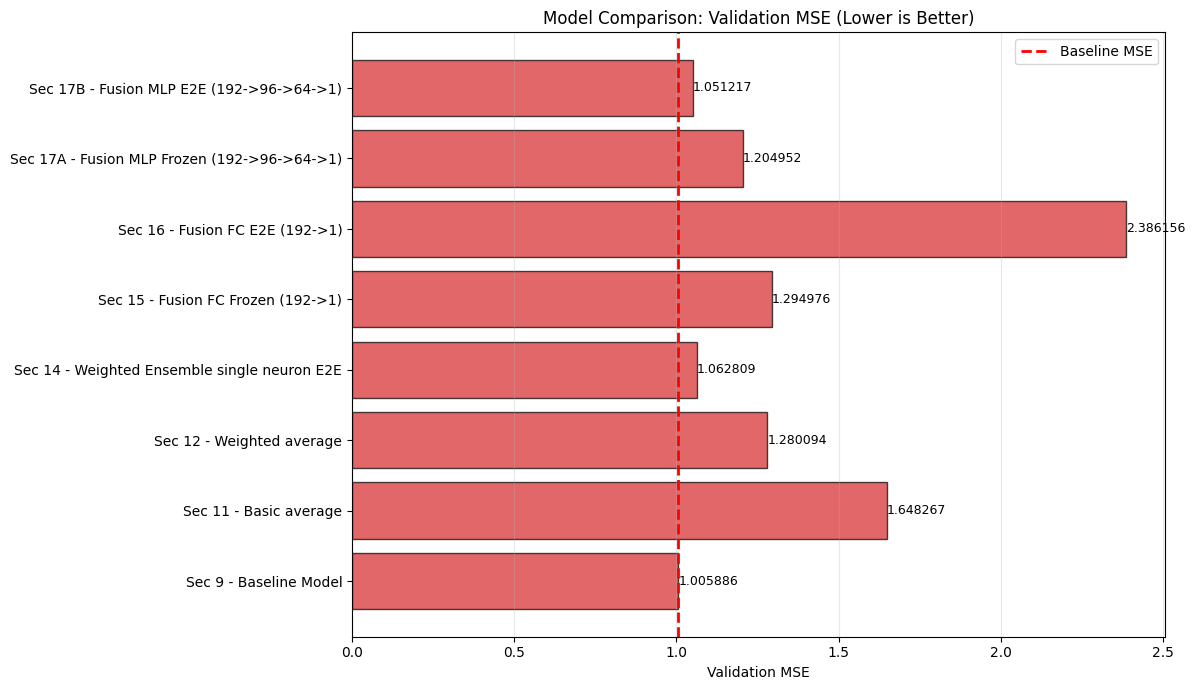


✓ MSE bar chart saved to c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\plots\section17_comprehensive_comparison_mse.png


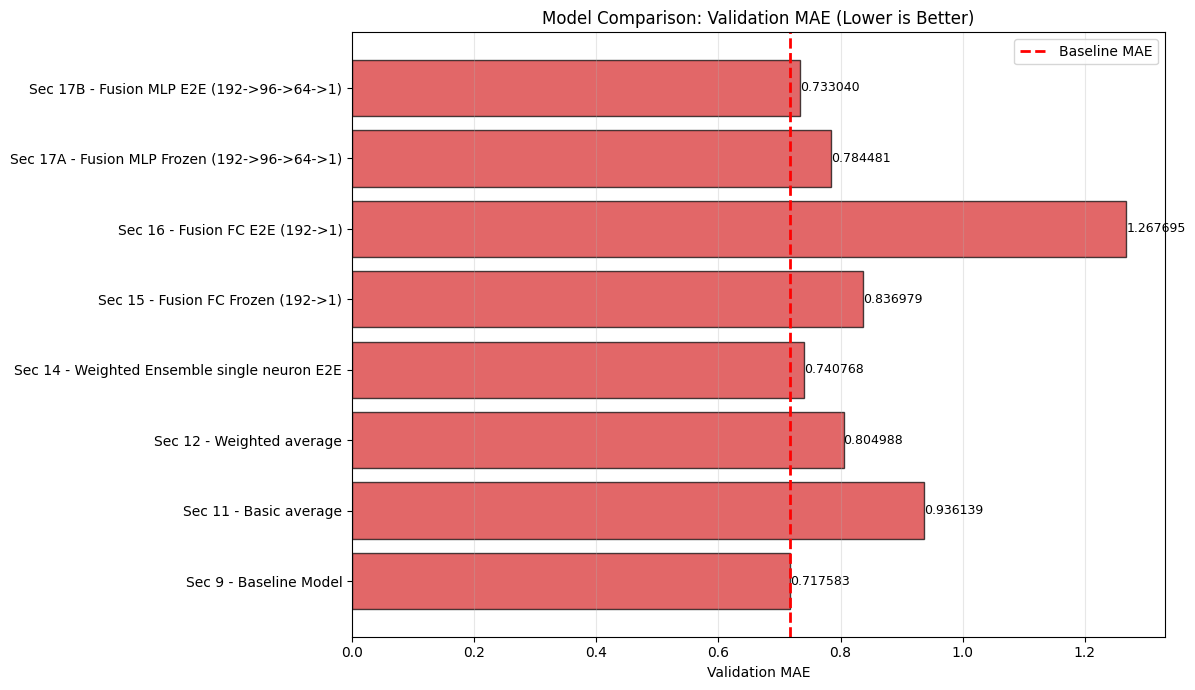

✓ MAE bar chart saved to c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\plots\section17_comprehensive_comparison_mae.png


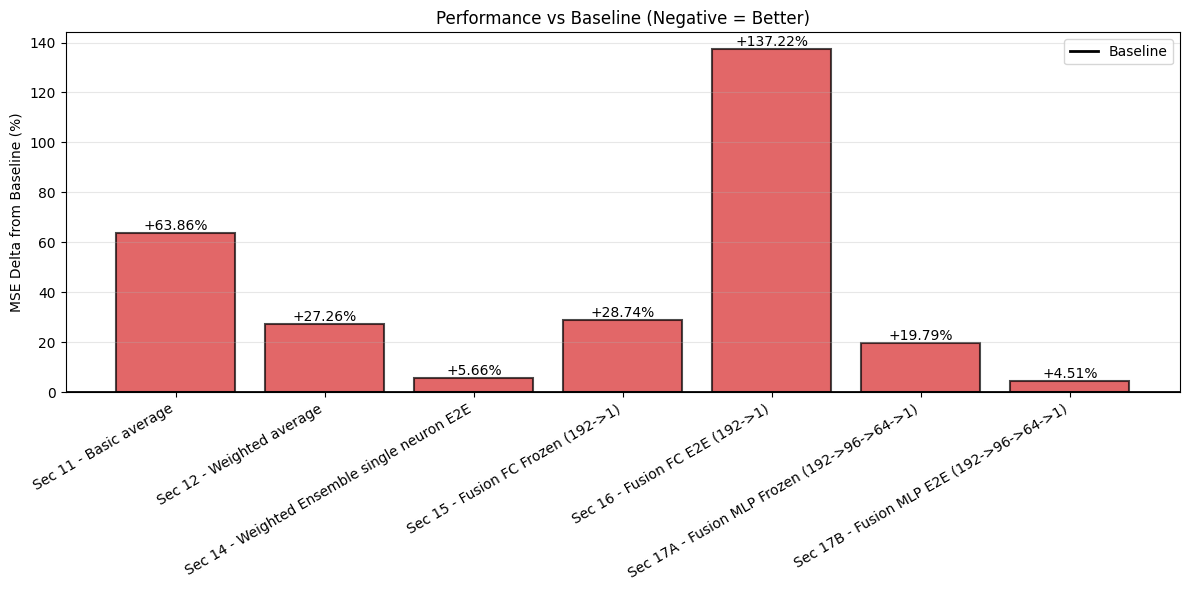

✓ Delta chart saved to c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\plots\section17_delta_from_baseline.png


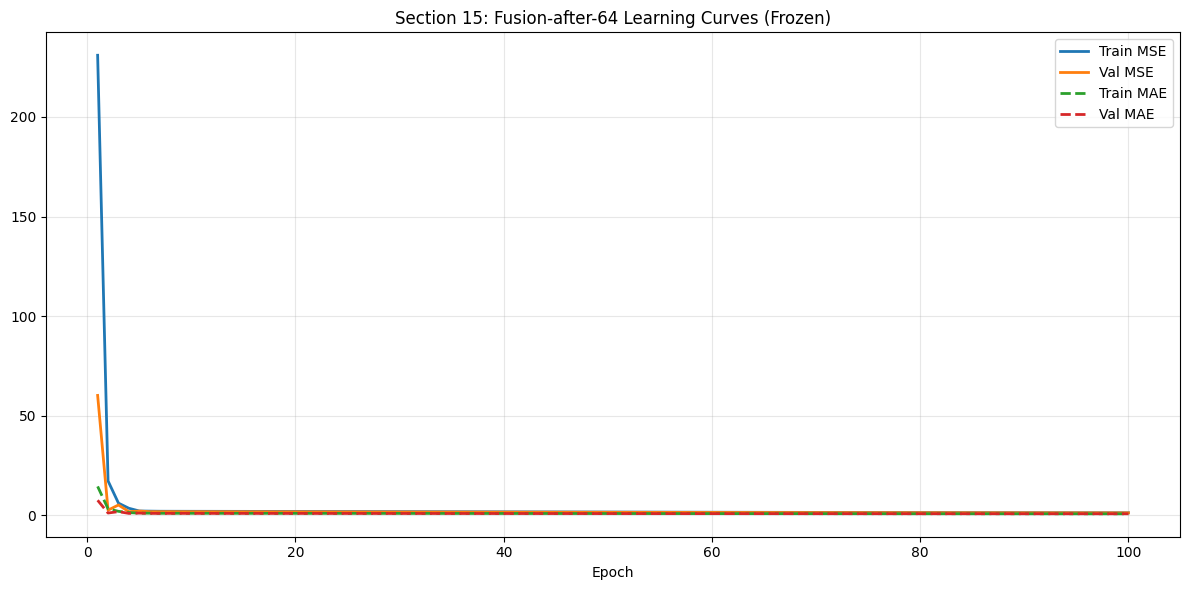

✓ Section 15 fusion learning curves saved to c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\plots\section17_fusion15_learning_curves.png


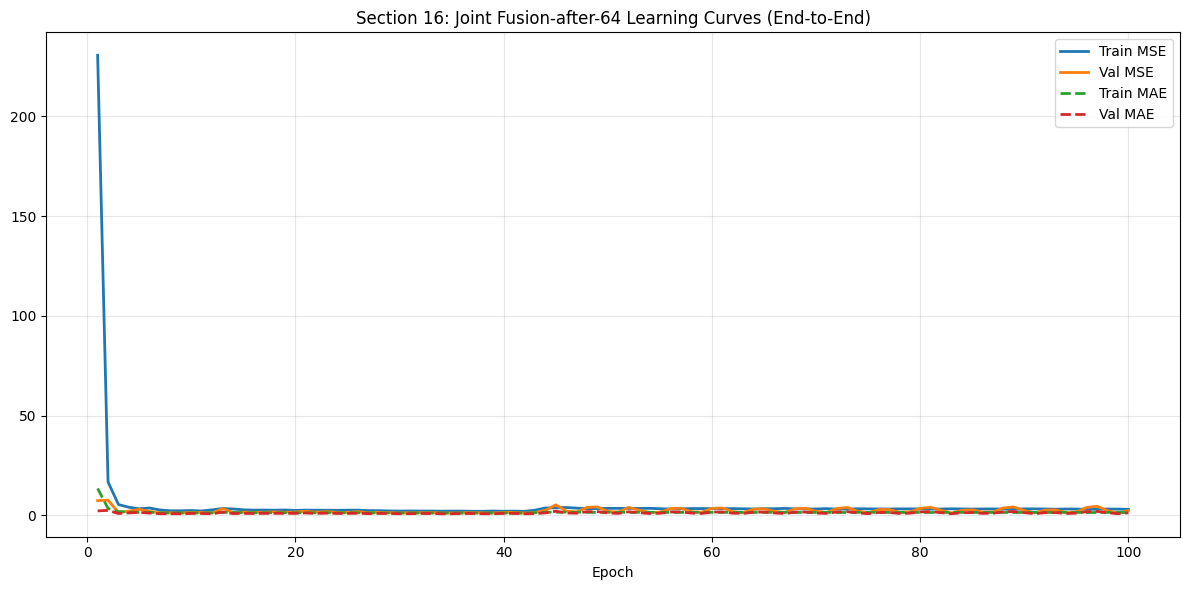

✓ Section 16 joint fusion learning curves saved to c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\plots\section17_joint_fusion16_learning_curves.png


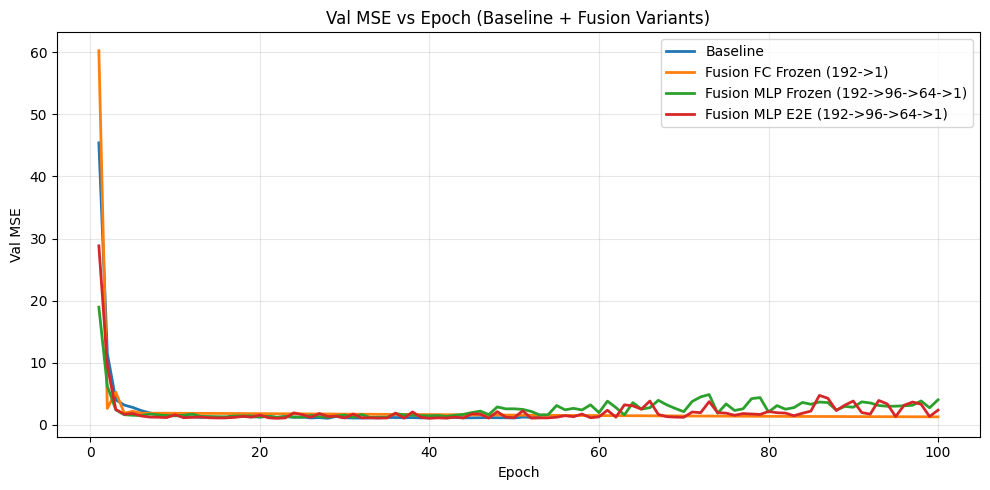

✓ Saved: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\plots\section17_val_mse_fusion_mlp_vs_baseline.png


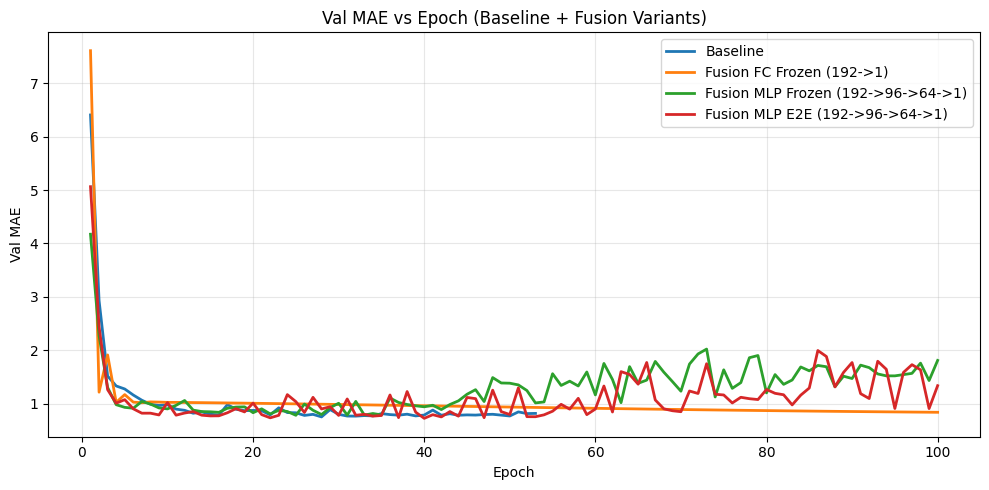

✓ Saved: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\plots\section17_val_mae_fusion_mlp_vs_baseline.png

✓ Comparison table saved to c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\summaries\section17_comprehensive_comparison.csv

Section 17 Complete - All visualizations and summaries generated!


In [70]:
# =========================
# SECTION 17
# COMPREHENSIVE COMPARISON (All Methods)  (FIXED)
# =========================
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "="*110)
print("SECTION 17: COMPREHENSIVE COMPARISON (Baseline + Ensembles + Fusion Models)")
print("="*110)

# ----------------------------
# 0) Safeguards
# ----------------------------
required = ["baseline_val_mse", "baseline_val_mae", "PLOTS_DIR", "SUMMARIES_DIR"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required vars for Section 17: {missing}")

# If the user didn't run sections that define these, we just skip those rows/plots.
# Also: allow both naming conventions for fusion mlp sections
if "fusion_mlp_frozen_metrics" not in globals() and "fusion_mlp_frozen_metrics" in locals():
    pass  # no-op, just to keep intent obvious

# ----------------------------
# 1) Build comparison table
# ----------------------------
rows = []

def _add_row_if_ok(method, section, mse, mae):
    if mse is None or mae is None:
        return
    try:
        rows.append({
            "Method": method,
            "Section": section,
            "Val MSE": float(mse),
            "Val MAE": float(mae),
        })
    except Exception:
        return

# Baseline
_add_row_if_ok("Baseline Model", "Sec 9", baseline_val_mse, baseline_val_mae)

# Sec 11 avg ensemble
_add_row_if_ok("Basic average", "Sec 11",
               globals().get("ensemble_val_mse", None),
               globals().get("ensemble_val_mae", None))

# Sec 12 calculated weights
_add_row_if_ok("Weighted average", "Sec 12",
               globals().get("calc_weighted_val_mse", None),
               globals().get("calc_weighted_val_mae", None))

# Sec 13 learned weights (frozen)
_add_row_if_ok("Weighted Ensemble single neuron Frozen", "Sec 13",
               globals().get("learned_weighted_val_mse", None),
               globals().get("learned_weighted_val_mae", None))

# Sec 14 joint training
_add_row_if_ok("Weighted Ensemble single neuron E2E", "Sec 14",
               globals().get("joint_ensemble_mse", None),
               globals().get("joint_ensemble_mae", None))

# Sec 15 fusion-after-64 frozen encoders
if "fusion64_frozen_metrics" in globals():
    _add_row_if_ok("Fusion FC Frozen (192->1)", "Sec 15",
                   fusion64_frozen_metrics.get("val_mse", None),
                   fusion64_frozen_metrics.get("val_mae", None))

# Sec 16 fusion-after-64 end-to-end
if "joint_fusion64_metrics" in globals():
    _add_row_if_ok("Fusion FC E2E (192->1)", "Sec 16",
                   joint_fusion64_metrics.get("val_mse", None),
                   joint_fusion64_metrics.get("val_mae", None))

# Sec 17A fusion MLP frozen
if "fusion_mlp_frozen_metrics" in globals():
    _add_row_if_ok("Fusion MLP Frozen (192->96->64->1)", "Sec 17A",
                   fusion_mlp_frozen_metrics.get("val_mse", None),
                   fusion_mlp_frozen_metrics.get("val_mae", None))

# Sec 17B fusion MLP end-to-end (your 17A2)
if "fusion_mlp_joint_metrics" in globals():
    _add_row_if_ok("Fusion MLP E2E (192->96->64->1)", "Sec 17B",
                   fusion_mlp_joint_metrics.get("val_mse", None),
                   fusion_mlp_joint_metrics.get("val_mae", None))

df_compare = pd.DataFrame(rows)
if df_compare.empty:
    raise RuntimeError("Comparison table is empty. At minimum, baseline_val_mse/baseline_val_mae must exist.")

# Delta vs baseline (%)
df_compare["MSE Delta (%)"] = ((df_compare["Val MSE"] - float(baseline_val_mse)) / float(baseline_val_mse)) * 100.0
df_compare["MAE Delta (%)"] = ((df_compare["Val MAE"] - float(baseline_val_mae)) / float(baseline_val_mae)) * 100.0

# Sort by section order
section_order = {"Sec 9": 0, "Sec 11": 1, "Sec 12": 2, "Sec 13": 3, "Sec 14": 4, "Sec 15": 5, "Sec 16": 6, "Sec 17A": 7, "Sec 17B": 8}
df_compare["section_sort"] = df_compare["Section"].map(section_order).fillna(999).astype(int)
df_compare = df_compare.sort_values("section_sort").drop("section_sort", axis=1).reset_index(drop=True)

# Combined label for plots
df_compare["Label"] = df_compare["Section"] + " - " + df_compare["Method"]

print("\n" + "="*110)
print("COMPARISON TABLE: Validation Metrics (Lower is Better)")
print("="*110)
print(df_compare.to_string(index=False, justify="left", float_format=lambda x: f"{x:.6f}"))

# Identify best model
best_idx = df_compare["Val MSE"].idxmin()
best_method = df_compare.loc[best_idx, "Method"]
best_mse = df_compare.loc[best_idx, "Val MSE"]
best_improvement = -df_compare.loc[best_idx, "MSE Delta (%)"]

print("\n" + "="*110)
print(f"🏆 BEST MODEL: {best_method}")
print(f"   Val MSE: {best_mse:.6f}")
if best_improvement > 0:
    print(f"   Improvement over Baseline: {best_improvement:.2f}%")
else:
    print(f"   Performance vs Baseline: {-best_improvement:.2f}% worse")
print("="*110)

# ----------------------------
# 2) Weight summary (if available)
# ----------------------------
print("\n" + "="*110)
print("ENSEMBLE WEIGHTS SUMMARY (Fin / Cre / Meta)")
print("="*110)
if "calculated_weights" in globals():
    print(f"Sec 12 (Calculated)   : {calculated_weights[0]:.4f} / {calculated_weights[1]:.4f} / {calculated_weights[2]:.4f}")
if "learned_weights" in globals():
    print(f"Sec 13 (Learned/Froz.): {learned_weights[0]:.4f} / {learned_weights[1]:.4f} / {learned_weights[2]:.4f}")
if "joint_learned_weights" in globals():
    print(f"Sec 14 (Joint Train.) : {joint_learned_weights[0]:.4f} / {joint_learned_weights[1]:.4f} / {joint_learned_weights[2]:.4f}")
print("Sec 15 (Fusion-64 Frz): Frozen encoders + learned fusion head (192->1)")
print("Sec 16 (Fusion-64 E2E): Joint training of encoders + fusion head (192->1)")
print("Sec 17A (Fusion MLP Frz): Frozen encoders + fusion MLP head")
print("Sec 17B (Fusion MLP E2E): Joint training of encoders + fusion MLP head")
print("="*110)

# ----------------------------
# 3) Visualization 1: Bar chart comparison (NO SUBPLOTS -> split into 2 figs)
# ----------------------------
# MSE barh
plt.figure(figsize=(12, 7))
colors_mse = ['#d62728' if x >= 0 else '#2ca02c' for x in df_compare["MSE Delta (%)"]]
bars_mse = plt.barh(df_compare["Label"], df_compare["Val MSE"], color=colors_mse, alpha=0.7, edgecolor='black')
plt.axvline(x=float(baseline_val_mse), color='red', linestyle='--', linewidth=2, label='Baseline MSE')
plt.xlabel("Validation MSE")
plt.title("Model Comparison: Validation MSE (Lower is Better)")
plt.grid(axis='x', alpha=0.3)
plt.legend()

for bar in bars_mse:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{width:.6f}',
             ha='left', va='center', fontsize=9)

plt.tight_layout()
plot_path = PLOTS_DIR / "section17_comprehensive_comparison_mse.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✓ MSE bar chart saved to {plot_path}")

# MAE barh
plt.figure(figsize=(12, 7))
colors_mae = ['#d62728' if x >= 0 else '#2ca02c' for x in df_compare["MAE Delta (%)"]]
bars_mae = plt.barh(df_compare["Label"], df_compare["Val MAE"], color=colors_mae, alpha=0.7, edgecolor='black')
plt.axvline(x=float(baseline_val_mae), color='red', linestyle='--', linewidth=2, label='Baseline MAE')
plt.xlabel("Validation MAE")
plt.title("Model Comparison: Validation MAE (Lower is Better)")
plt.grid(axis='x', alpha=0.3)
plt.legend()

for bar in bars_mae:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{width:.6f}',
             ha='left', va='center', fontsize=9)

plt.tight_layout()
plot_path = PLOTS_DIR / "section17_comprehensive_comparison_mae.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ MAE bar chart saved to {plot_path}")

# ----------------------------
# 4) Visualization 2: Delta from Baseline (MSE)
# ----------------------------
df_delta = df_compare[df_compare["Method"] != "Baseline Model"].copy()
if not df_delta.empty:
    plt.figure(figsize=(12, 6))
    x_pos = np.arange(len(df_delta))
    bars = plt.bar(
        x_pos, df_delta["MSE Delta (%)"],
        color=['#2ca02c' if d < 0 else '#d62728' for d in df_delta["MSE Delta (%)"]],
        alpha=0.7, edgecolor='black', linewidth=1.5
    )
    plt.xticks(x_pos, df_delta["Label"], rotation=30, ha='right')
    plt.axhline(y=0, color='black', linestyle='-', linewidth=2, label='Baseline')
    plt.ylabel("MSE Delta from Baseline (%)")
    plt.title("Performance vs Baseline (Negative = Better)")
    plt.grid(axis='y', alpha=0.3)
    plt.legend()

    for bar, val in zip(bars, df_delta["MSE Delta (%)"]):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2, height,
            f'{val:+.2f}%',
            ha='center', va='bottom' if height > 0 else 'top',
            fontsize=10
        )

    plt.tight_layout()
    plot_path = PLOTS_DIR / "section17_delta_from_baseline.png"
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Delta chart saved to {plot_path}")
else:
    print("Skipping delta plot (no non-baseline rows).")

# ----------------------------
# 5) Visualization 3: Fusion-after-64 Learning Curve (Section 15)
# ----------------------------
if "fusion_history" in globals() and isinstance(fusion_history, dict) and len(fusion_history.get("epoch", [])) > 0:
    plt.figure(figsize=(12, 6))
    epochs = fusion_history["epoch"]
    plt.plot(epochs, fusion_history["train_mse"], label="Train MSE", linewidth=2)
    plt.plot(epochs, fusion_history["val_mse"],   label="Val MSE", linewidth=2)
    plt.plot(epochs, fusion_history["train_mae"], label="Train MAE", linewidth=2, linestyle="--")
    plt.plot(epochs, fusion_history["val_mae"],   label="Val MAE", linewidth=2, linestyle="--")
    plt.xlabel("Epoch")
    plt.title("Section 15: Fusion-after-64 Learning Curves (Frozen)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plot_path = PLOTS_DIR / "section17_fusion15_learning_curves.png"
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Section 15 fusion learning curves saved to {plot_path}")

# ----------------------------
# 6) Visualization 4: Joint Fusion Learning Curve (Section 16)
# ----------------------------
if "joint_fusion_history" in globals() and isinstance(joint_fusion_history, dict) and len(joint_fusion_history.get("epoch", [])) > 0:
    plt.figure(figsize=(12, 6))
    epochs = joint_fusion_history["epoch"]
    plt.plot(epochs, joint_fusion_history["train_mse"], label="Train MSE", linewidth=2)
    plt.plot(epochs, joint_fusion_history["val_mse"],   label="Val MSE", linewidth=2)
    plt.plot(epochs, joint_fusion_history["train_mae"], label="Train MAE", linewidth=2, linestyle="--")
    plt.plot(epochs, joint_fusion_history["val_mae"],   label="Val MAE", linewidth=2, linestyle="--")
    plt.xlabel("Epoch")
    plt.title("Section 16: Joint Fusion-after-64 Learning Curves (End-to-End)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plot_path = PLOTS_DIR / "section17_joint_fusion16_learning_curves.png"
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Section 16 joint fusion learning curves saved to {plot_path}")

# ----------------------------
# 7) Visualization 5: Val MSE curves (Baseline vs Fusion variants)
# ----------------------------
def _plot_val_curves(curves: dict, ylabel: str, title: str, out_path):
    plt.figure(figsize=(10, 5))
    for label, values in curves.items():
        epochs = np.arange(1, len(values) + 1)
        plt.plot(epochs, values, label=label, linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved: {out_path}")

curves_mse = {}
if "results_history" in globals() and "baseline" in results_history and len(results_history["baseline"].get("val_mse", [])) > 0:
    curves_mse["Baseline"] = results_history["baseline"]["val_mse"]
if "fusion_history" in globals() and len(fusion_history.get("val_mse", [])) > 0:
    curves_mse["Fusion FC Frozen (192->1)"] = fusion_history["val_mse"]
if "fusion_mlp_frozen_history" in globals() and len(fusion_mlp_frozen_history.get("val_mse", [])) > 0:
    curves_mse["Fusion MLP Frozen (192->96->64->1)"] = fusion_mlp_frozen_history["val_mse"]
if "fusion_mlp_joint_history" in globals() and len(fusion_mlp_joint_history.get("val_mse", [])) > 0:
    curves_mse["Fusion MLP E2E (192->96->64->1)"] = fusion_mlp_joint_history["val_mse"]

if len(curves_mse) >= 2:
    plot_path = PLOTS_DIR / "section17_val_mse_fusion_mlp_vs_baseline.png"
    _plot_val_curves(curves_mse, "Val MSE", "Val MSE vs Epoch (Baseline + Fusion Variants)", plot_path)
else:
    print("Skipping Val MSE comparison plot (insufficient histories).")

# ----------------------------
# 8) Visualization 6: Val MAE curves (Baseline vs Fusion variants)
# ----------------------------
curves_mae = {}
if "results_history" in globals() and "baseline" in results_history and len(results_history["baseline"].get("val_mae", [])) > 0:
    curves_mae["Baseline"] = results_history["baseline"]["val_mae"]
if "fusion_history" in globals() and len(fusion_history.get("val_mae", [])) > 0:
    curves_mae["Fusion FC Frozen (192->1)"] = fusion_history["val_mae"]
if "fusion_mlp_frozen_history" in globals() and len(fusion_mlp_frozen_history.get("val_mae", [])) > 0:
    curves_mae["Fusion MLP Frozen (192->96->64->1)"] = fusion_mlp_frozen_history["val_mae"]
if "fusion_mlp_joint_history" in globals() and len(fusion_mlp_joint_history.get("val_mae", [])) > 0:
    curves_mae["Fusion MLP E2E (192->96->64->1)"] = fusion_mlp_joint_history["val_mae"]

if len(curves_mae) >= 2:
    plot_path = PLOTS_DIR / "section17_val_mae_fusion_mlp_vs_baseline.png"
    _plot_val_curves(curves_mae, "Val MAE", "Val MAE vs Epoch (Baseline + Fusion Variants)", plot_path)
else:
    print("Skipping Val MAE comparison plot (insufficient histories).")

# ----------------------------
# 9) Save comparison summary
# ----------------------------
summary_path = SUMMARIES_DIR / "section17_comprehensive_comparison.csv"
df_compare.to_csv(summary_path, index=False)
print(f"\n✓ Comparison table saved to {summary_path}")

print("\n" + "="*110)
print("Section 17 Complete - All visualizations and summaries generated!")
print("="*110)

## Test set evaluation
Evaluate held-out test performance using the saved predictions.

SECTION 18: TEST SET EVALUATION (LOG1P SCALE)

Note: Test set contains 816 samples (held untouched)
This is the FIRST and FINAL evaluation on held-out test data
y_test range: [9.3683, 21.4506]

[0/9] Loaded pre-computed test predictions from disk
      Using 815 samples (shape alignment)
⚠️ Baseline CSV preds differ from checkpoint -> using checkpoint baseline for comparisons.

[1/9] Baseline Model (Sec 9)...
   Source: checkpoint | Test MSE: 1.003073, Test MAE: 0.696218

[2/9] Feature Group Models (Sec 11)...
   Financial | Test MSE: 5.261590, Test MAE: 1.820884
   Creative  | Test MSE: 3.348515, Test MAE: 1.427589
   Metadata  | Test MSE: 4.215440, Test MAE: 1.618979

[3/9] Calculated Weights Ensemble (Sec 12)...
   Test MSE: 4.377038, Test MAE: 1.660485

[4/9] Learned Weights Ensemble - Frozen (Sec 13)...
   Test MSE: 4.506556, Test MAE: 1.684672

[5/9] Joint End-to-End Ensemble (Sec 14)...
   Test MSE: 3.738361, Test MAE: 1.524075

[6/9] Fusion-after-64 (Frozen, Sec 15)...
   Test 

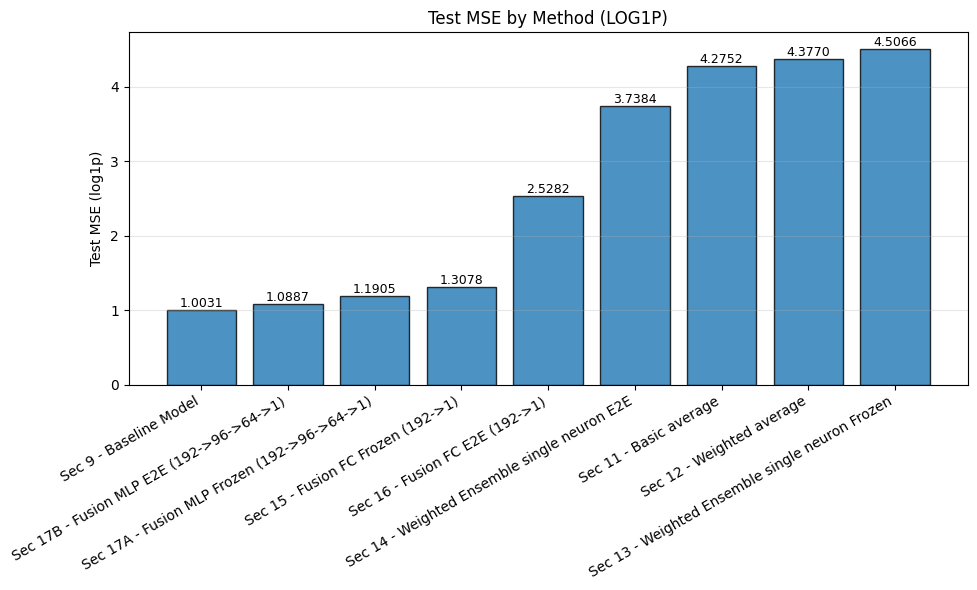

✓ Saved: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\plots\section18_test_mse.png


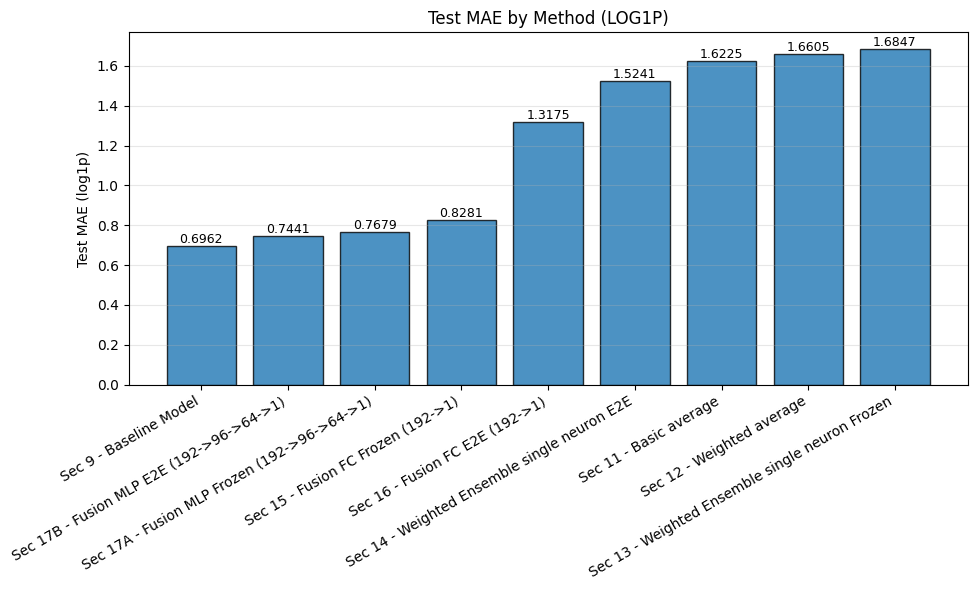

✓ Saved: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\plots\section18_test_mae.png


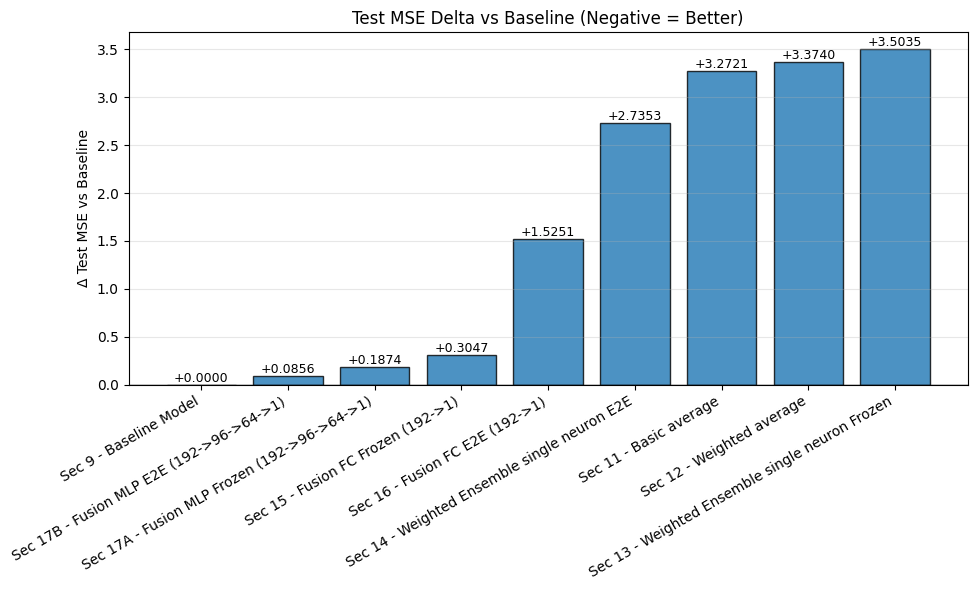

✓ Saved: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\seperated_vs_shared_encoding\plots\section18_test_mse_delta.png

Done.


In [69]:
# =========================
# SECTION 18 (FIXED): TEST SET EVALUATION (LOG1P SCALE)
# =========================
# Key fixes vs your draft:
# 1) Sec 15 / Sec 16 test preds were WRONG (you used simple average). Now we use the actual trained fusion head/models.
# 2) More robust: if something wasn’t trained / variables missing -> we skip that method instead of crashing.
# 3) No subplots (split figures) – same style as the fixed Section 17.

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("="*90)
print("SECTION 18: TEST SET EVALUATION (LOG1P SCALE)")
print("="*90)

# ----------------------------
# 0) Required checks
# ----------------------------
required = ["ALL_FEATURES_DIR", "TARGET_COL", "PREDICTIONS_DIR", "PLOTS_DIR", "SUMMARIES_DIR", "device"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Missing required vars for Section 18: {missing}")

# ----------------------------
# 1) Load y_test (log1p)
# ----------------------------
test_df = pd.read_csv(Path(ALL_FEATURES_DIR) / "test.csv")
y_test = np.log1p(test_df[TARGET_COL].values).astype(np.float32)

print(f"\nNote: Test set contains {len(test_df)} samples (held untouched)")
print("This is the FIRST and FINAL evaluation on held-out test data")
print(f"y_test range: [{y_test.min():.4f}, {y_test.max():.4f}]")

# ----------------------------
# 2) Load pre-computed test predictions (baseline / groups) from disk
# ----------------------------
pred_csv_path = Path(PREDICTIONS_DIR) / "test_predictions_all_models.csv"
test_preds_df = pd.read_csv(pred_csv_path)

# must exist in CSV:
baseline_test_pred  = test_preds_df["baseline"].values.astype(np.float32)
financial_test_pred = test_preds_df["financial"].values.astype(np.float32)
creative_test_pred  = test_preds_df["creative"].values.astype(np.float32)
metadata_test_pred  = test_preds_df["metadata"].values.astype(np.float32)

min_len = min(len(y_test), len(baseline_test_pred), len(financial_test_pred), len(creative_test_pred), len(metadata_test_pred))
y_test = y_test[:min_len]
baseline_test_pred  = baseline_test_pred[:min_len]
financial_test_pred = financial_test_pred[:min_len]
creative_test_pred  = creative_test_pred[:min_len]
metadata_test_pred  = metadata_test_pred[:min_len]

print("\n[0/9] Loaded pre-computed test predictions from disk")
print(f"      Using {min_len} samples (shape alignment)")

# Optional baseline checkpoint sanity (if available)
baseline_pred_source = "csv"
if "models" in globals() and "baseline" in models and "baseline_X_test" in globals():
    try:
        models["baseline"]["model"].eval()
        with torch.no_grad():
            Xb = torch.from_numpy(baseline_X_test[:min_len]).float().to(device)
            pred_ckpt = models["baseline"]["model"](Xb).detach().cpu().numpy().reshape(-1).astype(np.float32)
        mse_ckpt = float(np.mean((pred_ckpt - y_test) ** 2))
        mse_csv  = float(np.mean((baseline_test_pred - y_test) ** 2))
        if abs(mse_ckpt - mse_csv) > 1e-3:
            print("⚠️ Baseline CSV preds differ from checkpoint -> using checkpoint baseline for comparisons.")
            baseline_test_pred = pred_ckpt
            baseline_pred_source = "checkpoint"
    except Exception as e:
        print(f"[0b] Baseline checkpoint sanity skipped: {e}")

# ----------------------------
# 3) Helpers
# ----------------------------
def _mse(a, b): return float(np.mean((a - b) ** 2))
def _mae(a, b): return float(np.mean(np.abs(a - b)))

def _try_get(name, default=None):
    return globals().get(name, default)

# For TabularRegressor: encoder(x) is the 64-d rep
@torch.no_grad()
def _encode64(model, X):
    return model.encoder(X)

# ----------------------------
# 4) Metrics for base models (baseline + groups)
# ----------------------------
print("\n[1/9] Baseline Model (Sec 9)...")
baseline_test_mse = _mse(baseline_test_pred, y_test)
baseline_test_mae = _mae(baseline_test_pred, y_test)
print(f"   Source: {baseline_pred_source} | Test MSE: {baseline_test_mse:.6f}, Test MAE: {baseline_test_mae:.6f}")

print("\n[2/9] Feature Group Models (Sec 11)...")
financial_test_mse = _mse(financial_test_pred, y_test)
financial_test_mae = _mae(financial_test_pred, y_test)
creative_test_mse  = _mse(creative_test_pred, y_test)
creative_test_mae  = _mae(creative_test_pred, y_test)
metadata_test_mse  = _mse(metadata_test_pred, y_test)
metadata_test_mae  = _mae(metadata_test_pred, y_test)
print(f"   Financial | Test MSE: {financial_test_mse:.6f}, Test MAE: {financial_test_mae:.6f}")
print(f"   Creative  | Test MSE: {creative_test_mse:.6f}, Test MAE: {creative_test_mae:.6f}")
print(f"   Metadata  | Test MSE: {metadata_test_mse:.6f}, Test MAE: {metadata_test_mae:.6f}")

# ----------------------------
# 5) Ensembles using weights (Sec 12/13/14)
# ----------------------------
print("\n[3/9] Calculated Weights Ensemble (Sec 12)...")
calc_test_mse = None
calc_test_mae = None
if "calculated_weights" in globals():
    w = np.array(calculated_weights, dtype=np.float32).reshape(-1)
    ensemble_calc_test_pred = (w[0]*financial_test_pred + w[1]*creative_test_pred + w[2]*metadata_test_pred).astype(np.float32)
    calc_test_mse = _mse(ensemble_calc_test_pred, y_test)
    calc_test_mae = _mae(ensemble_calc_test_pred, y_test)
    print(f"   Test MSE: {calc_test_mse:.6f}, Test MAE: {calc_test_mae:.6f}")
else:
    print("   Skipping: calculated_weights not found.")

print("\n[4/9] Learned Weights Ensemble - Frozen (Sec 13)...")
learned_test_mse = None
learned_test_mae = None
if "learned_weights" in globals():
    w = np.array(learned_weights, dtype=np.float32).reshape(-1)
    ensemble_learned_test_pred = (w[0]*financial_test_pred + w[1]*creative_test_pred + w[2]*metadata_test_pred).astype(np.float32)
    learned_test_mse = _mse(ensemble_learned_test_pred, y_test)
    learned_test_mae = _mae(ensemble_learned_test_pred, y_test)
    print(f"   Test MSE: {learned_test_mse:.6f}, Test MAE: {learned_test_mae:.6f}")
else:
    print("   Skipping: learned_weights not found.")

print("\n[5/9] Joint End-to-End Ensemble (Sec 14)...")
joint_test_mse = None
joint_test_mae = None
if "joint_learned_weights" in globals():
    w = np.array(joint_learned_weights, dtype=np.float32).reshape(-1)
    ensemble_joint_test_pred = (w[0]*financial_test_pred + w[1]*creative_test_pred + w[2]*metadata_test_pred).astype(np.float32)
    joint_test_mse = _mse(ensemble_joint_test_pred, y_test)
    joint_test_mae = _mae(ensemble_joint_test_pred, y_test)
    print(f"   Test MSE: {joint_test_mse:.6f}, Test MAE: {joint_test_mae:.6f}")
else:
    print("   Skipping: joint_learned_weights not found.")

# ----------------------------
# 6) Build group-specific test tensors (for fusion models)
#     IMPORTANT: we prefer using baseline_X_test slices (shared feature space) if available.
#     Otherwise we fall back to the tensor-building function you already wrote (if it exists).
# ----------------------------
test_tensors_by_group = {}

if "baseline_X_test" in globals() and "FEATURE_GROUPS" in globals() and "_group_shared_indices" in globals():
    # Preferred: use the exact same shared-feature indexing logic you used in training
    for g in ["financial", "creative", "metadata"]:
        idxs = _group_shared_indices(FEATURE_GROUPS[g])
        Xg = baseline_X_test[:min_len, idxs].astype(np.float32)
        test_tensors_by_group[g] = torch.tensor(Xg, dtype=torch.float32)
else:
    # Fallback: use your helper if it exists
    if "_build_group_test_tensor" in globals() and "FEATURE_GROUPS" in globals():
        for g in ["financial", "creative", "metadata"]:
            test_tensors_by_group[g] = _build_group_test_tensor(g, FEATURE_GROUPS[g])[:min_len]
    else:
        test_tensors_by_group = None
        print("\n⚠️ Could not build group-specific test tensors (missing baseline_X_test/_group_shared_indices OR _build_group_test_tensor).")
        print("   => Skipping Sec 15/16/17 test evaluation (fusion models).")

# ----------------------------
# 7) Sec 15 (Frozen fusion 64) - use actual trained fusion head + frozen encoders from Section 15
# ----------------------------
print("\n[6/9] Fusion-after-64 (Frozen, Sec 15)...")
fusion64_frozen_test_mse = None
fusion64_frozen_test_mae = None

if test_tensors_by_group is not None and ("fusion_head" in globals()) and ("encoders" in globals()):
    try:
        fusion_head.eval()
        for g in ["financial", "creative", "metadata"]:
            encoders[g].eval()

        with torch.no_grad():
            Xtf = test_tensors_by_group["financial"].to(device)
            Xtc = test_tensors_by_group["creative"].to(device)
            Xtm = test_tensors_by_group["metadata"].to(device)

            h_fin  = encoders["financial"](Xtf)
            h_cre  = encoders["creative"](Xtc)
            h_meta = encoders["metadata"](Xtm)

            h = torch.cat([h_fin, h_cre, h_meta], dim=1)  # (N,192)
            pred = fusion_head(h).detach().cpu().numpy().reshape(-1).astype(np.float32)

        fusion64_frozen_test_mse = _mse(pred, y_test)
        fusion64_frozen_test_mae = _mae(pred, y_test)
        print(f"   Test MSE: {fusion64_frozen_test_mse:.6f}, Test MAE: {fusion64_frozen_test_mae:.6f}")
    except Exception as e:
        print(f"   Skipping Sec 15 fusion eval (error): {e}")
else:
    print("   Skipping: missing 'fusion_head' and/or 'encoders' from Section 15.")

# ----------------------------
# 8) Sec 16 (End-to-end fusion 64) - use actual trained joint_fusion_head + joint_fusion_encoders
# ----------------------------
print("\n[7/9] Joint Fusion-after-64 (End-to-end, Sec 16)...")
joint_fusion64_test_mse = None
joint_fusion64_test_mae = None

if test_tensors_by_group is not None and ("joint_fusion_head" in globals()) and ("joint_fusion_encoders" in globals()):
    try:
        joint_fusion_head.eval()
        for g in ["financial", "creative", "metadata"]:
            joint_fusion_encoders[g]["model"].eval()

        with torch.no_grad():
            Xtf = test_tensors_by_group["financial"].to(device)
            Xtc = test_tensors_by_group["creative"].to(device)
            Xtm = test_tensors_by_group["metadata"].to(device)

            h_fin  = joint_fusion_encoders["financial"]["model"].encoder(Xtf)
            h_cre  = joint_fusion_encoders["creative"]["model"].encoder(Xtc)
            h_meta = joint_fusion_encoders["metadata"]["model"].encoder(Xtm)

            h = torch.cat([h_fin, h_cre, h_meta], dim=1)
            pred = joint_fusion_head(h).detach().cpu().numpy().reshape(-1).astype(np.float32)

        joint_fusion64_test_mse = _mse(pred, y_test)
        joint_fusion64_test_mae = _mae(pred, y_test)
        print(f"   Test MSE: {joint_fusion64_test_mse:.6f}, Test MAE: {joint_fusion64_test_mae:.6f}")
    except Exception as e:
        print(f"   Skipping Sec 16 fusion eval (error): {e}")
else:
    print("   Skipping: missing 'joint_fusion_head' and/or 'joint_fusion_encoders' from Section 16.")

# ----------------------------
# 9) Sec 17A frozen fusion MLP head (if you trained it)
# ----------------------------
print("\n[8/9] Fusion MLP (Frozen, Sec 17A)...")
fusion_mlp_frozen_test_mse = None
fusion_mlp_frozen_test_mae = None

# Accept either name: fusion_mlp_frozen_head (your older) or fusion_head_mlp_frozen (if you used another)
_frozen_head = _try_get("fusion_mlp_frozen_head", None)
if _frozen_head is None:
    _frozen_head = _try_get("fusion_mlp_frozen_model", None)  # unlikely, but safe

# Need group models for encoders: models[g]["model"]
if test_tensors_by_group is not None and (_frozen_head is not None) and ("models" in globals()):
    try:
        _frozen_head.eval()
        for g in ["financial", "creative", "metadata"]:
            models[g]["model"].eval()

        with torch.no_grad():
            Xtf = test_tensors_by_group["financial"].to(device)
            Xtc = test_tensors_by_group["creative"].to(device)
            Xtm = test_tensors_by_group["metadata"].to(device)

            # Use encoder(x) directly (64-d)
            h_fin  = models["financial"]["model"].encoder(Xtf)
            h_cre  = models["creative"]["model"].encoder(Xtc)
            h_meta = models["metadata"]["model"].encoder(Xtm)

            h = torch.cat([h_fin, h_cre, h_meta], dim=1)
            pred = _frozen_head(h).detach().cpu().numpy().reshape(-1).astype(np.float32)

        fusion_mlp_frozen_test_mse = _mse(pred, y_test)
        fusion_mlp_frozen_test_mae = _mae(pred, y_test)
        print(f"   Test MSE: {fusion_mlp_frozen_test_mse:.6f}, Test MAE: {fusion_mlp_frozen_test_mae:.6f}")
    except Exception as e:
        print(f"   Skipping Sec 17A frozen fusion MLP eval (error): {e}")
else:
    print("   Skipping: missing frozen fusion MLP head and/or group models.")

# ----------------------------
# 10) Sec 17B end-to-end fusion MLP joint model (if trained)
# ----------------------------
print("\n[9/9] Fusion MLP (End-to-End, Sec 17B)...")
fusion_mlp_joint_test_mse = None
fusion_mlp_joint_test_mae = None

_joint_model = _try_get("joint_fusion_mlp_model", None)  # your Section 17A2 name
if _joint_model is None:
    _joint_model = _try_get("joint_fusion_mlp", None)

if test_tensors_by_group is not None and _joint_model is not None:
    try:
        _joint_model.eval()
        with torch.no_grad():
            Xtf = test_tensors_by_group["financial"].to(device)
            Xtc = test_tensors_by_group["creative"].to(device)
            Xtm = test_tensors_by_group["metadata"].to(device)
            pred = _joint_model(Xtf, Xtc, Xtm).detach().cpu().numpy().reshape(-1).astype(np.float32)

        fusion_mlp_joint_test_mse = _mse(pred, y_test)
        fusion_mlp_joint_test_mae = _mae(pred, y_test)
        print(f"   Test MSE: {fusion_mlp_joint_test_mse:.6f}, Test MAE: {fusion_mlp_joint_test_mae:.6f}")
    except Exception as e:
        print(f"   Skipping Sec 17B joint fusion MLP eval (error): {e}")
else:
    print("   Skipping: missing joint fusion MLP model.")

# ----------------------------
# 11) Build comparison table (only for methods that exist)
# ----------------------------
comparison_rows = []

def _push(section, method, mse, mae):
    if mse is None or mae is None:
        return
    comparison_rows.append({
        "Section": section,
        "Method": method,
        "Test MSE": float(mse),
        "Test MAE": float(mae),
        "MSE vs Baseline": float(mse) - float(baseline_test_mse),
        "MAE vs Baseline": float(mae) - float(baseline_test_mae),
    })

_push("Sec 9",  "Baseline Model", baseline_test_mse, baseline_test_mae)

# optional: feature group avg (just a summary row)
_push("Sec 11", "Basic average", (financial_test_mse+creative_test_mse+metadata_test_mse)/3.0,
     (financial_test_mae+creative_test_mae+metadata_test_mae)/3.0)

_push("Sec 12", "Weighted average", calc_test_mse, calc_test_mae)
_push("Sec 13", "Weighted Ensemble single neuron Frozen", learned_test_mse, learned_test_mae)
_push("Sec 14", "Weighted Ensemble single neuron E2E", joint_test_mse, joint_test_mae)

_push("Sec 15", "Fusion FC Frozen (192->1)", fusion64_frozen_test_mse, fusion64_frozen_test_mae)
_push("Sec 16", "Fusion FC E2E (192->1)", joint_fusion64_test_mse, joint_fusion64_test_mae)

_push("Sec 17A", "Fusion MLP Frozen (192->96->64->1)", fusion_mlp_frozen_test_mse, fusion_mlp_frozen_test_mae)
_push("Sec 17B", "Fusion MLP E2E (192->96->64->1)", fusion_mlp_joint_test_mse, fusion_mlp_joint_test_mae)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values("Test MSE", ascending=True).reset_index(drop=True)
comparison_df["Label"] = comparison_df["Section"] + " - " + comparison_df["Method"]

print("\n" + "="*90)
print("TEST SET COMPARISON TABLE (LOG1P SCALE) — lower is better")
print("="*90)
print(comparison_df.to_string(index=False))

best_idx = comparison_df["Test MSE"].idxmin()
best_name = comparison_df.loc[best_idx, "Method"]
best_mse  = float(comparison_df.loc[best_idx, "Test MSE"])
best_mae  = float(comparison_df.loc[best_idx, "Test MAE"])
improvement_pct = ((baseline_test_mse - best_mse) / baseline_test_mse) * 100.0

print("\n" + "="*90)
print(f"BEST TEST MODEL: {best_name}")
print(f"Test MSE: {best_mse:.6f} | Test MAE: {best_mae:.6f}")
print(f"Improvement vs baseline (MSE): {improvement_pct:+.2f}%")
print("="*90)

# Save table
comparison_csv_path = SUMMARIES_DIR / "test_set_comparison.csv"
comparison_df.to_csv(comparison_csv_path, index=False)
print(f"\n✓ Saved: {comparison_csv_path}")

# ----------------------------
# 12) Visualizations (NO SUBPLOTS)
# ----------------------------
# Plot A: Test MSE by method
plt.figure(figsize=(10, 6))
x = np.arange(len(comparison_df))
plt.bar(x, comparison_df["Test MSE"].values, edgecolor="black", alpha=0.8)
plt.xticks(x, comparison_df["Label"].values, rotation=30, ha="right")
plt.ylabel("Test MSE (log1p)")
plt.title("Test MSE by Method (LOG1P)")
plt.grid(True, alpha=0.3, axis="y")
for i, v in enumerate(comparison_df["Test MSE"].values):
    plt.text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plot_path = PLOTS_DIR / "section18_test_mse.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {plot_path}")

# Plot B: Test MAE by method
plt.figure(figsize=(10, 6))
plt.bar(x, comparison_df["Test MAE"].values, edgecolor="black", alpha=0.8)
plt.xticks(x, comparison_df["Label"].values, rotation=30, ha="right")
plt.ylabel("Test MAE (log1p)")
plt.title("Test MAE by Method (LOG1P)")
plt.grid(True, alpha=0.3, axis="y")
for i, v in enumerate(comparison_df["Test MAE"].values):
    plt.text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plot_path = PLOTS_DIR / "section18_test_mae.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {plot_path}")

# Plot C: MSE delta vs baseline
plt.figure(figsize=(10, 6))
delta = comparison_df["Test MSE"].values - float(baseline_test_mse)
plt.bar(x, delta, edgecolor="black", alpha=0.8)
plt.axhline(0, color="black", linewidth=1)
plt.xticks(x, comparison_df["Label"].values, rotation=30, ha="right")
plt.ylabel("Δ Test MSE vs Baseline")
plt.title("Test MSE Delta vs Baseline (Negative = Better)")
plt.grid(True, alpha=0.3, axis="y")
for i, v in enumerate(delta):
    plt.text(i, v, f"{v:+.4f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
plt.tight_layout()
plot_path = PLOTS_DIR / "section18_test_mse_delta.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {plot_path}")

print("\nDone.")